In [ ]:
!pip install scipy
!pip install seaborn

In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Community-centered Analysis**

## General statistics

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime

# Load the CSV file
file_path = '/content/drive/My Drive/Projects/Reddit_rules/2024_ChenEtAl_rulechange/sub_level_data.csv'
df = pd.read_csv(file_path)

# Set up visualization style
plt.style.use('default')
sns.set_palette("husl")

print("=" * 80)
print("REDDIT COMMUNITY STATISTICAL ANALYSIS")
print("=" * 80)

# 1. BASIC DATASET INFORMATION
print("\n1. DATASET OVERVIEW")
print("-" * 40)
print(f"Total number of communities: {len(df)}")
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\nMissing values per column:")
print(df.isnull().sum())

# 2. DESCRIPTIVE STATISTICS
print("\n2. DESCRIPTIVE STATISTICS")
print("-" * 40)

# Numerical columns for analysis
numerical_cols = ['added', 'changed', 'deleted', 'unchanged',
                 'subscribers_1', 'subscribers_2', 'rules_1', 'rules_2', 'age_in_months']

print("\nBasic Statistics for Numerical Variables:")
print(df[numerical_cols].describe().round(2))

# 3. RULE CHANGE ANALYSIS
print("\n3. RULE CHANGE PATTERNS")
print("-" * 40)

# Total rule changes
df['total_changes'] = df['added'] + df['changed'] + df['deleted']
df['change_rate'] = df['total_changes'] / (df['rules_1'] + 1)  # +1 to avoid division by zero

print(f"\nCommunities with any rule changes: {(df['total_changes'] > 0).sum()} ({(df['total_changes'] > 0).mean()*100:.1f}%)")
print(f"Communities with no changes: {(df['total_changes'] == 0).sum()} ({(df['total_changes'] == 0).mean()*100:.1f}%)")

print("\nRule Change Statistics:")
print(f"Average rules added: {df['added'].mean():.2f} (±{df['added'].std():.2f})")
print(f"Average rules changed: {df['changed'].mean():.2f} (±{df['changed'].std():.2f})")
print(f"Average rules deleted: {df['deleted'].mean():.2f} (±{df['deleted'].std():.2f})")
print(f"Average rules unchanged: {df['unchanged'].mean():.2f} (±{df['unchanged'].std():.2f})")

# Distribution of change types
change_distribution = pd.DataFrame({
    'Added': [(df['added'] > 0).sum()],
    'Changed': [(df['changed'] > 0).sum()],
    'Deleted': [(df['deleted'] > 0).sum()],
    'No Changes': [(df['total_changes'] == 0).sum()]
})
print("\nCommunities by Change Type:")
print(change_distribution.T)

# 4. SUBSCRIBER GROWTH ANALYSIS
print("\n4. SUBSCRIBER GROWTH ANALYSIS")
print("-" * 40)

df['subscriber_growth'] = df['subscribers_2'] - df['subscribers_1']
df['growth_rate'] = ((df['subscribers_2'] - df['subscribers_1']) / (df['subscribers_1'] + 1)) * 100

print(f"\nAverage subscriber growth: {df['subscriber_growth'].mean():.0f} (±{df['subscriber_growth'].std():.0f})")
print(f"Median subscriber growth: {df['subscriber_growth'].median():.0f}")
print(f"Average growth rate: {df['growth_rate'].mean():.2f}%")
print(f"Median growth rate: {df['growth_rate'].median():.2f}%")

# Categorize communities by size
df['size_category'] = pd.cut(df['subscribers_2'],
                             bins=[0, 1000, 10000, 100000, float('inf')],
                             labels=['Small (<1k)', 'Medium (1k-10k)',
                                    'Large (10k-100k)', 'Very Large (>100k)'])

print("\nCommunity Distribution by Size:")
print(df['size_category'].value_counts().sort_index())

# 5. CORRELATION ANALYSIS
print("\n5. CORRELATION ANALYSIS")
print("-" * 40)

# Select variables for correlation
corr_vars = ['added', 'changed', 'deleted', 'unchanged', 'total_changes',
            'subscribers_1', 'subscribers_2', 'subscriber_growth',
            'growth_rate', 'rules_1', 'rules_2', 'age_in_months']

# Calculate correlation matrix
corr_matrix = df[corr_vars].corr()

# Find strongest correlations
print("\nStrongest Correlations (|r| > 0.3):")
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.3:
            strong_corr.append((corr_matrix.columns[i],
                              corr_matrix.columns[j],
                              corr_matrix.iloc[i, j]))

strong_corr.sort(key=lambda x: abs(x[2]), reverse=True)
for var1, var2, corr in strong_corr[:10]:
    print(f"  {var1} ↔ {var2}: {corr:.3f}")

# 6. COMMUNITY AGE ANALYSIS
print("\n6. COMMUNITY AGE ANALYSIS")
print("-" * 40)

print(f"Average community age: {df['age_in_months'].mean():.1f} months")
print(f"Median community age: {df['age_in_months'].median():.1f} months")
print(f"Oldest community: {df['age_in_months'].max():.0f} months ({df['age_in_months'].max()/12:.1f} years)")
print(f"Youngest community: {df['age_in_months'].min():.0f} months")

# Age categories
df['age_category'] = pd.cut(df['age_in_months'],
                            bins=[0, 12, 36, 60, float('inf')],
                            labels=['New (<1yr)', 'Young (1-3yrs)',
                                   'Established (3-5yrs)', 'Mature (>5yrs)'])

print("\nCommunity Distribution by Age:")
print(df['age_category'].value_counts().sort_index())

# 7. RULE COMPLEXITY ANALYSIS
print("\n7. RULE COMPLEXITY ANALYSIS")
print("-" * 40)

df['rule_change'] = df['rules_2'] - df['rules_1']

print(f"Average initial rules: {df['rules_1'].mean():.2f} (±{df['rules_1'].std():.2f})")
print(f"Average final rules: {df['rules_2'].mean():.2f} (±{df['rules_2'].std():.2f})")
print(f"Average rule count change: {df['rule_change'].mean():.2f}")

print("\nRule Count Changes:")
print(f"Communities that increased rules: {(df['rule_change'] > 0).sum()} ({(df['rule_change'] > 0).mean()*100:.1f}%)")
print(f"Communities that decreased rules: {(df['rule_change'] < 0).sum()} ({(df['rule_change'] < 0).mean()*100:.1f}%)")
print(f"Communities with same rule count: {(df['rule_change'] == 0).sum()} ({(df['rule_change'] == 0).mean()*100:.1f}%)")

# 8. STATISTICAL TESTS
print("\n8. STATISTICAL SIGNIFICANCE TESTS")
print("-" * 40)

# Test if rule changes are related to community size
communities_with_changes = df[df['total_changes'] > 0]['subscribers_1']
communities_without_changes = df[df['total_changes'] == 0]['subscribers_1']

if len(communities_with_changes) > 0 and len(communities_without_changes) > 0:
    # Mann-Whitney U test (non-parametric)
    statistic, pvalue = stats.mannwhitneyu(communities_with_changes,
                                           communities_without_changes,
                                           alternative='two-sided')
    print(f"\nMann-Whitney U test (size difference between communities with/without changes):")
    print(f"  U-statistic: {statistic:.2f}")
    print(f"  p-value: {pvalue:.4f}")
    if pvalue < 0.05:
        print(f"  Result: Significant difference in size (p < 0.05)")
    else:
        print(f"  Result: No significant difference in size (p >= 0.05)")

# Test correlation between subscriber growth and rule changes
if df['subscriber_growth'].std() > 0 and df['total_changes'].std() > 0:
    corr_coef, p_value = stats.spearmanr(df['subscriber_growth'], df['total_changes'])
    print(f"\nSpearman correlation (subscriber growth vs. total rule changes):")
    print(f"  Correlation coefficient: {corr_coef:.4f}")
    print(f"  p-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"  Result: Significant correlation (p < 0.05)")
    else:
        print(f"  Result: No significant correlation (p >= 0.05)")

# 9. OUTLIER DETECTION
print("\n9. OUTLIER ANALYSIS")
print("-" * 40)

def detect_outliers(series, threshold=3):
    z_scores = np.abs(stats.zscore(series.dropna()))
    return sum(z_scores > threshold)

print("Outliers detected (z-score > 3):")
outlier_cols = ['added', 'changed', 'deleted', 'subscribers_2', 'subscriber_growth']
for col in outlier_cols:
    n_outliers = detect_outliers(df[col])
    print(f"  {col}: {n_outliers} outliers ({n_outliers/len(df)*100:.2f}%)")

# 10. SUMMARY INSIGHTS
print("\n10. KEY INSIGHTS SUMMARY")
print("-" * 40)

# Calculate some key metrics
active_communities = (df['total_changes'] > 0).mean() * 100
avg_growth = df['growth_rate'].median()
most_common_change = 'added' if df['added'].sum() > df['deleted'].sum() else 'deleted'

print(f"• {active_communities:.1f}% of communities made at least one rule change")
print(f"• Median subscriber growth rate: {avg_growth:.1f}%")
print(f"• Most common rule change type: Rules {most_common_change}")
print(f"• Larger communities tend to have {'more' if corr_matrix.loc['subscribers_1', 'rules_1'] > 0 else 'fewer'} rules")
print(f"• Average community age: {df['age_in_months'].mean()/12:.1f} years")

# Identify most active communities
df['activity_score'] = df['total_changes'] + (df['growth_rate'] / 100)
top_active = df.nlargest(5, 'activity_score')[['communityID', 'total_changes', 'growth_rate', 'subscribers_2']]
print("\nMost Active Communities (by rule changes and growth):")
print(top_active.to_string(index=False))

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)

REDDIT COMMUNITY STATISTICAL ANALYSIS

1. DATASET OVERVIEW
----------------------------------------
Total number of communities: 130851
Dataset shape: (130851, 13)

Column names and types:
communityID       object
added            float64
changed          float64
deleted          float64
unchanged        float64
subscribers_1      int64
subscribers_2      int64
rules_1            int64
rules_2            int64
timestamp_1      float64
timestamp_2      float64
founding_date    float64
age_in_months    float64
dtype: object

Missing values per column:
communityID      0
added            0
changed          0
deleted          0
unchanged        0
subscribers_1    0
subscribers_2    0
rules_1          0
rules_2          0
timestamp_1      0
timestamp_2      0
founding_date    0
age_in_months    0
dtype: int64

2. DESCRIPTIVE STATISTICS
----------------------------------------

Basic Statistics for Numerical Variables:
           added    changed    deleted  unchanged  subscribers_1  \
count

## H1: Most communities primarily evolve through rule additions.

HYPOTHESIS 1 TESTING: Most communities primarily evolve through rule additions

Total communities analyzed: 130851
Communities with any rule changes: 6948 (5.3%)

TEST 1: DESCRIPTIVE ANALYSIS - CHANGE TYPE DISTRIBUTION

Total rule changes across all communities:
  Added:   16,705.0 (62.0%)
  Changed: 676.0 (2.5%)
  Deleted: 9,558.0 (35.5%)
  TOTAL:   26,939.0

Communities by dominant change type (excluding ties):
  added: 4395 communities (82.0%)
  deleted: 776 communities (14.5%)
  changed: 188 communities (3.5%)

Communities with ties: 1589 (22.9%)

TEST 2: BINOMIAL TEST - IS ADDITION THE MAJORITY STRATEGY?

Null Hypothesis: p(addition dominant) = 0.5
Alternative: p(addition dominant) > 0.5

Observed proportion: 0.820
Test statistic: 4395 out of 5359
P-value: 0.0000
95% CI for proportion: [0.811, 1.000]
RESULT: ✓ Additions are significantly dominant (p < 0.05)

TEST 3: CHI-SQUARE TEST - DEVIATION FROM EQUAL DISTRIBUTION

Null Hypothesis: All change types occur equally (1/3 each)
Obse

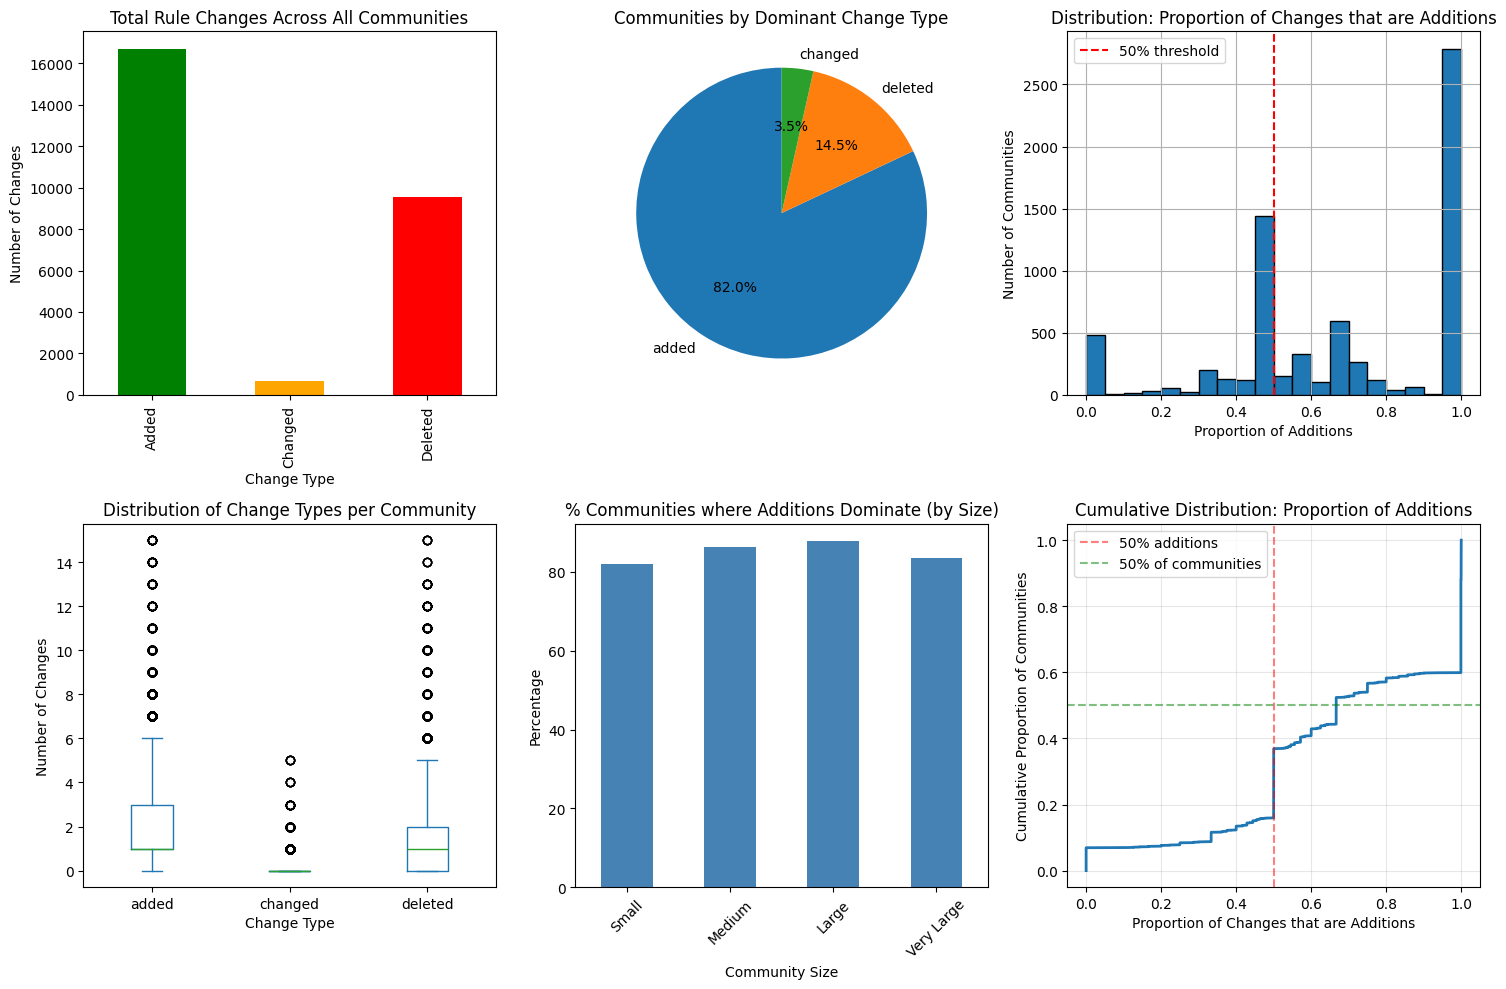

Visualizations saved as 'hypothesis1_analysis.png'

Analysis complete!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, binomtest, wilcoxon, friedmanchisquare
import warnings
warnings.filterwarnings('ignore')

# Load the data
file_path = '/content/drive/My Drive/Projects/Reddit_rules/2024_ChenEtAl_rulechange/sub_level_data.csv'
df = pd.read_csv(file_path)

print("=" * 80)
print("HYPOTHESIS 1 TESTING: Most communities primarily evolve through rule additions")
print("=" * 80)

# Filter to communities that made changes
df_changed = df[(df['added'] > 0) | (df['changed'] > 0) | (df['deleted'] > 0)].copy()

print(f"\nTotal communities analyzed: {len(df)}")
print(f"Communities with any rule changes: {len(df_changed)} ({len(df_changed)/len(df)*100:.1f}%)")

# ============================================================================
# TEST 1: DESCRIPTIVE ANALYSIS - DOMINANCE OF ADDITIONS
# ============================================================================
print("\n" + "="*60)
print("TEST 1: DESCRIPTIVE ANALYSIS - CHANGE TYPE DISTRIBUTION")
print("="*60)

# Calculate totals
total_added = df['added'].sum()
total_changed = df['changed'].sum()
total_deleted = df['deleted'].sum()
total_all_changes = total_added + total_changed + total_deleted

print(f"\nTotal rule changes across all communities:")
print(f"  Added:   {total_added:,} ({total_added/total_all_changes*100:.1f}%)")
print(f"  Changed: {total_changed:,} ({total_changed/total_all_changes*100:.1f}%)")
print(f"  Deleted: {total_deleted:,} ({total_deleted/total_all_changes*100:.1f}%)")
print(f"  TOTAL:   {total_all_changes:,}")

# Communities where each type dominates
df_changed['dominant_change'] = df_changed[['added', 'changed', 'deleted']].idxmax(axis=1)
df_changed['has_ties'] = (
    ((df_changed['added'] == df_changed['changed']) & (df_changed['added'] > 0)) |
    ((df_changed['added'] == df_changed['deleted']) & (df_changed['added'] > 0)) |
    ((df_changed['changed'] == df_changed['deleted']) & (df_changed['changed'] > 0))
)

print(f"\nCommunities by dominant change type (excluding ties):")
dominant_counts = df_changed[~df_changed['has_ties']]['dominant_change'].value_counts()
for change_type, count in dominant_counts.items():
    pct = count/len(df_changed[~df_changed['has_ties']])*100
    print(f"  {change_type}: {count} communities ({pct:.1f}%)")

print(f"\nCommunities with ties: {df_changed['has_ties'].sum()} ({df_changed['has_ties'].mean()*100:.1f}%)")

# ============================================================================
# TEST 2: ONE-SAMPLE PROPORTION TEST
# ============================================================================
print("\n" + "="*60)
print("TEST 2: BINOMIAL TEST - IS ADDITION THE MAJORITY STRATEGY?")
print("="*60)

# For communities with changes, test if >50% primarily use additions
communities_addition_dominant = (df_changed[~df_changed['has_ties']]['dominant_change'] == 'added').sum()
total_communities_no_ties = len(df_changed[~df_changed['has_ties']])

if total_communities_no_ties > 0:
    result = binomtest(communities_addition_dominant,
                       total_communities_no_ties,
                       p=0.5,
                       alternative='greater')

    print(f"\nNull Hypothesis: p(addition dominant) = 0.5")
    print(f"Alternative: p(addition dominant) > 0.5")
    print(f"\nObserved proportion: {communities_addition_dominant/total_communities_no_ties:.3f}")
    print(f"Test statistic: {communities_addition_dominant} out of {total_communities_no_ties}")
    print(f"P-value: {result.pvalue:.4f}")
    print(f"95% CI for proportion: [{result.proportion_ci(confidence_level=0.95).low:.3f}, {result.proportion_ci(confidence_level=0.95).high:.3f}]")

    if result.pvalue < 0.05:
        print("RESULT: ✓ Additions are significantly dominant (p < 0.05)")
    else:
        print("RESULT: ✗ Additions are not significantly dominant (p ≥ 0.05)")

# ============================================================================
# TEST 3: CHI-SQUARE GOODNESS OF FIT
# ============================================================================
print("\n" + "="*60)
print("TEST 3: CHI-SQUARE TEST - DEVIATION FROM EQUAL DISTRIBUTION")
print("="*60)

# Test if the distribution differs from equal proportions (1/3 each)
observed = [total_added, total_changed, total_deleted]
expected_equal = [total_all_changes/3] * 3

chi2_stat, p_value = stats.chisquare(observed, expected_equal)

print(f"\nNull Hypothesis: All change types occur equally (1/3 each)")
print(f"Observed frequencies: Added={total_added}, Changed={total_changed}, Deleted={total_deleted}")
print(f"Expected (if equal): {total_all_changes/3:.1f} each")
print(f"\nChi-square statistic: {chi2_stat:.2f}")
print(f"P-value: {p_value:.4e}")
print(f"Effect size (Cramér's V): {np.sqrt(chi2_stat/total_all_changes):.3f}")

if p_value < 0.05:
    print("RESULT: ✓ Distribution significantly differs from equal proportions")
else:
    print("RESULT: ✗ Distribution does not differ from equal proportions")

# ============================================================================
# TEST 4: PAIRED COMPARISONS (WILCOXON SIGNED-RANK)
# ============================================================================
print("\n" + "="*60)
print("TEST 4: WILCOXON SIGNED-RANK - PAIRED COMPARISONS")
print("="*60)

# For communities with changes, compare additions vs other types
df_test = df_changed[['added', 'changed', 'deleted']].copy()

# Test 1: Added vs Changed
stat_ac, p_ac = wilcoxon(df_test['added'], df_test['changed'], alternative='greater', zero_method='wilcox')
print(f"\nAdded vs Changed:")
print(f"  Median Added: {df_test['added'].median()}, Median Changed: {df_test['changed'].median()}")
print(f"  Wilcoxon statistic: {stat_ac:.2f}")
print(f"  P-value (one-sided): {p_ac:.4f}")
print(f"  Result: {'✓ Added > Changed' if p_ac < 0.05 else '✗ No significant difference'}")

# Test 2: Added vs Deleted
stat_ad, p_ad = wilcoxon(df_test['added'], df_test['deleted'], alternative='greater', zero_method='wilcox')
print(f"\nAdded vs Deleted:")
print(f"  Median Added: {df_test['added'].median()}, Median Deleted: {df_test['deleted'].median()}")
print(f"  Wilcoxon statistic: {stat_ad:.2f}")
print(f"  P-value (one-sided): {p_ad:.4f}")
print(f"  Result: {'✓ Added > Deleted' if p_ad < 0.05 else '✗ No significant difference'}")

# Bonferroni correction for multiple comparisons
bonferroni_alpha = 0.05 / 2
print(f"\nWith Bonferroni correction (α = {bonferroni_alpha:.3f}):")
print(f"  Added > Changed: {'✓ Significant' if p_ac < bonferroni_alpha else '✗ Not significant'}")
print(f"  Added > Deleted: {'✓ Significant' if p_ad < bonferroni_alpha else '✗ Not significant'}")

# ============================================================================
# TEST 5: FRIEDMAN TEST - OVERALL RANKING
# ============================================================================
print("\n" + "="*60)
print("TEST 5: FRIEDMAN TEST - RANKING OF CHANGE TYPES")
print("="*60)

# Friedman test for related samples
if len(df_test) > 0:
    stat_friedman, p_friedman = friedmanchisquare(df_test['added'],
                                                   df_test['changed'],
                                                   df_test['deleted'])

    print(f"\nNull Hypothesis: All change types have the same distribution")
    print(f"Friedman statistic: {stat_friedman:.2f}")
    print(f"P-value: {p_friedman:.4e}")

    if p_friedman < 0.05:
        print("RESULT: ✓ Significant differences exist among change types")

        # Post-hoc: Calculate mean ranks
        ranks = df_test[['added', 'changed', 'deleted']].rank(axis=1, method='average')
        mean_ranks = ranks.mean().sort_values(ascending=False)
        print("\nMean ranks (higher = more frequent):")
        for change_type, rank in mean_ranks.items():
            print(f"  {change_type}: {rank:.2f}")
    else:
        print("RESULT: ✗ No significant differences among change types")

# ============================================================================
# TEST 6: EFFECT SIZE AND PRACTICAL SIGNIFICANCE
# ============================================================================
print("\n" + "="*60)
print("TEST 6: EFFECT SIZES AND PRACTICAL SIGNIFICANCE")
print("="*60)

# Cohen's d for paired comparisons
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    return (x.mean() - y.mean()) / np.sqrt(((nx-1)*x.std()**2 + (ny-1)*y.std()**2) / dof)

d_ac = cohens_d(df_test['added'], df_test['changed'])
d_ad = cohens_d(df_test['added'], df_test['deleted'])

print(f"\nCohen's d effect sizes:")
print(f"  Added vs Changed: {d_ac:.3f} ({'large' if abs(d_ac) > 0.8 else 'medium' if abs(d_ac) > 0.5 else 'small'})")
print(f"  Added vs Deleted: {d_ad:.3f} ({'large' if abs(d_ad) > 0.8 else 'medium' if abs(d_ad) > 0.5 else 'small'})")

# Proportion of variance explained
df_changed['total_changes'] = df_changed['added'] + df_changed['changed'] + df_changed['deleted']
df_changed['prop_added'] = df_changed['added'] / (df_changed['total_changes'] + 0.001)

print(f"\nProportion of changes that are additions:")
print(f"  Mean: {df_changed['prop_added'].mean():.3f}")
print(f"  Median: {df_changed['prop_added'].median():.3f}")
print(f"  Communities where >50% changes are additions: {(df_changed['prop_added'] > 0.5).sum()} ({(df_changed['prop_added'] > 0.5).mean()*100:.1f}%)")
print(f"  Communities where >75% changes are additions: {(df_changed['prop_added'] > 0.75).sum()} ({(df_changed['prop_added'] > 0.75).mean()*100:.1f}%)")

# ============================================================================
# TEST 7: SUBGROUP ANALYSIS
# ============================================================================
print("\n" + "="*60)
print("TEST 7: SUBGROUP ANALYSIS - CONSISTENCY ACROSS COMMUNITY TYPES")
print("="*60)

# Test by community size
df_changed['size_category'] = pd.cut(df_changed['subscribers_2'],
                                      bins=[0, 1000, 10000, 100000, float('inf')],
                                      labels=['Small', 'Medium', 'Large', 'Very Large'])

print("\nProportion where additions dominate, by community size:")
for size in ['Small', 'Medium', 'Large', 'Very Large']:
    size_data = df_changed[df_changed['size_category'] == size]
    if len(size_data) > 0:
        prop = (size_data['dominant_change'] == 'added').mean()
        print(f"  {size}: {prop:.1%} (n={len(size_data)})")

# Test by community age
df_changed['age_category'] = pd.cut(df_changed['age_in_months'],
                                    bins=[0, 12, 36, 60, float('inf')],
                                    labels=['New', 'Young', 'Established', 'Mature'])

print("\nProportion where additions dominate, by community age:")
for age in ['New', 'Young', 'Established', 'Mature']:
    age_data = df_changed[df_changed['age_category'] == age]
    if len(age_data) > 0:
        prop = (age_data['dominant_change'] == 'added').mean()
        print(f"  {age}: {prop:.1%} (n={len(age_data)})")

# ============================================================================
# FINAL HYPOTHESIS EVALUATION
# ============================================================================
print("\n" + "="*80)
print("HYPOTHESIS 1 EVALUATION SUMMARY")
print("="*80)

# Compile evidence
evidence_for = []
evidence_against = []

# Check each test result
if total_added > total_changed and total_added > total_deleted:
    evidence_for.append("✓ Additions are the most frequent change type overall")
else:
    evidence_against.append("✗ Additions are not the most frequent change type")

if communities_addition_dominant/total_communities_no_ties > 0.5:
    evidence_for.append("✓ Majority of communities have additions as dominant change")
else:
    evidence_against.append("✗ Additions don't dominate in majority of communities")

if p_value < 0.05:
    evidence_for.append("✓ Change distribution significantly differs from equal")

if p_ac < 0.05:
    evidence_for.append("✓ Additions significantly exceed changes")
else:
    evidence_against.append("✗ Additions don't significantly exceed changes")

if p_ad < 0.05:
    evidence_for.append("✓ Additions significantly exceed deletions")
else:
    evidence_against.append("✗ Additions don't significantly exceed deletions")

if df_changed['prop_added'].median() > 0.5:
    evidence_for.append("✓ Median proportion of additions exceeds 50%")
else:
    evidence_against.append("✗ Median proportion of additions below 50%")

print("\nEvidence FOR hypothesis:")
for item in evidence_for:
    print(f"  {item}")

if evidence_against:
    print("\nEvidence AGAINST hypothesis:")
    for item in evidence_against:
        print(f"  {item}")

# Overall conclusion
support_score = len(evidence_for) / (len(evidence_for) + len(evidence_against))
print(f"\n{'='*60}")
print(f"OVERALL SUPPORT: {support_score:.1%}")
if support_score > 0.75:
    print("CONCLUSION: STRONG SUPPORT for Hypothesis 1")
    print("Most communities DO primarily evolve through rule additions")
elif support_score > 0.5:
    print("CONCLUSION: MODERATE SUPPORT for Hypothesis 1")
    print("Communities tend to evolve through additions, but with exceptions")
else:
    print("CONCLUSION: WEAK/NO SUPPORT for Hypothesis 1")
    print("Communities do NOT primarily evolve through rule additions")
print(f"{'='*60}")

# ============================================================================
# VISUALIZATION
# ============================================================================
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Bar chart of total changes
ax1 = axes[0, 0]
change_totals = pd.Series([total_added, total_changed, total_deleted],
                          index=['Added', 'Changed', 'Deleted'])
change_totals.plot(kind='bar', ax=ax1, color=['green', 'orange', 'red'])
ax1.set_title('Total Rule Changes Across All Communities')
ax1.set_ylabel('Number of Changes')
ax1.set_xlabel('Change Type')

# 2. Pie chart of dominant change types
ax2 = axes[0, 1]
dominant_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
ax2.set_title('Communities by Dominant Change Type')
ax2.set_ylabel('')

# 3. Distribution of proportion of additions
ax3 = axes[0, 2]
df_changed['prop_added'].hist(bins=20, ax=ax3, edgecolor='black')
ax3.axvline(0.5, color='red', linestyle='--', label='50% threshold')
ax3.set_title('Distribution: Proportion of Changes that are Additions')
ax3.set_xlabel('Proportion of Additions')
ax3.set_ylabel('Number of Communities')
ax3.legend()

# 4. Box plot comparing change types
ax4 = axes[1, 0]
df_test[['added', 'changed', 'deleted']].plot(kind='box', ax=ax4)
ax4.set_title('Distribution of Change Types per Community')
ax4.set_ylabel('Number of Changes')
ax4.set_xlabel('Change Type')

# 5. Additions by community size
ax5 = axes[1, 1]
size_props = df_changed.groupby('size_category')['dominant_change'].apply(
    lambda x: (x == 'added').mean() * 100
)
size_props.plot(kind='bar', ax=ax5, color='steelblue')
ax5.set_title('% Communities where Additions Dominate (by Size)')
ax5.set_ylabel('Percentage')
ax5.set_xlabel('Community Size')
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=45)

# 6. Cumulative distribution
ax6 = axes[1, 2]
sorted_props = np.sort(df_changed['prop_added'])
cumulative = np.arange(1, len(sorted_props) + 1) / len(sorted_props)
ax6.plot(sorted_props, cumulative, linewidth=2)
ax6.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='50% additions')
ax6.axhline(0.5, color='green', linestyle='--', alpha=0.5, label='50% of communities')
ax6.set_title('Cumulative Distribution: Proportion of Additions')
ax6.set_xlabel('Proportion of Changes that are Additions')
ax6.set_ylabel('Cumulative Proportion of Communities')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hypothesis1_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualizations saved as 'hypothesis1_analysis.png'")
print("\nAnalysis complete!")

### Level 1: comprehensive

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import binomtest, chi2_contingency, fisher_exact
import warnings
warnings.filterwarnings('ignore')

# Load the data
file_path = '/content/drive/My Drive/Projects/Reddit_rules/2024_ChenEtAl_rulechange/sub_level_data.csv'
df = pd.read_csv(file_path)

# --- FIX: Ensure numeric integer counts for tests ---
req_cols = ['added', 'changed', 'deleted']
missing = [c for c in req_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

df[req_cols] = df[req_cols].apply(pd.to_numeric, errors='coerce').fillna(0).astype('int64')

print("=" * 80)
print("DIRECT HYPOTHESIS TESTING: MAJORITY OF RULE CHANGES ARE ADDITIONS")
print("=" * 80)
print("\nHypothesis: More than 50% of all rule changes are additions")
print("=" * 80)

# ============================================================================
# LEVEL 1: AGGREGATE-LEVEL TESTS (All changes pooled)
# ============================================================================
print("\n" + "="*70)
print("LEVEL 1: AGGREGATE-LEVEL TESTS (Testing total changes across all communities)")
print("="*70)

# Calculate totals (ints)
total_added = int(df['added'].sum())
total_changed = int(df['changed'].sum())
total_deleted = int(df['deleted'].sum())
total_all = total_added + total_changed + total_deleted

if total_all == 0:
    raise ValueError("Total number of rule changes is 0 after cleaning; cannot run tests.")

print(f"\nTotal rule changes in dataset:")
print(f"  Additions:     {total_added:,} ({total_added/total_all*100:.2f}%)")
print(f"  Modifications: {total_changed:,} ({total_changed/total_all*100:.2f}%)")
print(f"  Deletions:     {total_deleted:,} ({total_deleted/total_all*100:.2f}%)")
print(f"  TOTAL:         {total_all:,}")

# ----------------------------------------------------------------------------
# Test 1.1: One-sample proportion test (Exact binomial)
# ----------------------------------------------------------------------------
print("\n" + "-"*60)
print("Test 1.1: EXACT BINOMIAL TEST")
print("-"*60)
print("H0: P(addition) = 0.5")
print("H1: P(addition) > 0.5")

result = binomtest(k=total_added, n=total_all, p=0.5, alternative='greater')
ci = result.proportion_ci(confidence_level=0.95, method='exact')

print(f"\nResults:")
print(f"  Observed proportion: {total_added/total_all:.4f}")
print(f"  Test statistic: {total_added} successes out of {total_all} trials")
print(f"  P-value: {result.pvalue:.2e}")
print(f"  95% CI: [{ci.low:.4f}, {ci.high:.4f}]")

if result.pvalue < 0.001:
    print("  **RESULT: HIGHLY SIGNIFICANT (p < 0.001) - Strong evidence additions are majority**")
elif result.pvalue < 0.05:
    print("  **RESULT: SIGNIFICANT (p < 0.05) - Additions are majority**")
else:
    print("  **RESULT: NOT SIGNIFICANT - Cannot conclude additions are majority**")

# ----------------------------------------------------------------------------
# Test 1.2: Multinomial goodness-of-fit test
# ----------------------------------------------------------------------------
print("\n" + "-"*60)
print("Test 1.2: MULTINOMIAL GOODNESS-OF-FIT TEST")
print("-"*60)
print("H0: P(added) = P(changed) = P(deleted) = 1/3")
print("H1: Probabilities are not equal")

observed = np.array([total_added, total_changed, total_deleted])
expected = np.array([total_all/3, total_all/3, total_all/3])
chi2_stat, p_value = stats.chisquare(observed, expected)

print(f"\nResults:")
print(f"  Observed: {observed}")
print(f"  Expected (under H0): {expected.astype(int)}")
print(f"  Chi-square statistic: {chi2_stat:.2f}")
print(f"  P-value: {p_value:.2e}")
print(f"  Effect size (Cramér's V): {np.sqrt(chi2_stat/total_all):.4f}")

if p_value < 0.001:
    print(f"  **RESULT: Distribution highly significantly differs from equal proportions**")

# Post-hoc: Test if additions > 1/3
z_score = (total_added/total_all - 1/3) / np.sqrt((1/3 * 2/3) / total_all)
p_one_third = stats.norm.sf(abs(z_score))
print(f"\nPost-hoc test - Is P(additions) > 1/3?")
print(f"  Z-score: {z_score:.2f}")
print(f"  P-value: {p_one_third:.2e}")
print(f"  **RESULT: {'YES' if p_one_third < 0.05 else 'NO'}**")

# ----------------------------------------------------------------------------
# Test 1.3: Manual Bootstrap confidence interval
# ----------------------------------------------------------------------------
print("\n" + "-"*60)
print("Test 1.3: BOOTSTRAP CONFIDENCE INTERVAL")
print("-"*60)

# Create bootstrap samples manually
n_bootstrap = 10000
np.random.seed(42)

# Create array of all changes
all_changes = np.concatenate([
    np.repeat('added', total_added),
    np.repeat('changed', total_changed),
    np.repeat('deleted', total_deleted)
])

# Perform bootstrap
bootstrap_props = []
for _ in range(n_bootstrap):
    sample = np.random.choice(all_changes, size=len(all_changes), replace=True)
    prop_added = (sample == 'added').mean()
    bootstrap_props.append(prop_added)

bootstrap_props = np.array(bootstrap_props)
ci_lower = np.percentile(bootstrap_props, 2.5)
ci_upper = np.percentile(bootstrap_props, 97.5)

print(f"Bootstrap results (n={n_bootstrap:,} iterations):")
print(f"  Mean proportion of additions: {bootstrap_props.mean():.4f}")
print(f"  95% Bootstrap CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"  Probability P(additions) > 0.5: {(bootstrap_props > 0.5).mean():.4f}")

if ci_lower > 0.5:
    print(f"  **RESULT: Lower bound > 0.5 - Strong evidence additions are majority**")
elif ci_lower > 1/3:
    print(f"  **RESULT: Additions significantly exceed equal proportion (1/3)**")


DIRECT HYPOTHESIS TESTING: MAJORITY OF RULE CHANGES ARE ADDITIONS

Hypothesis: More than 50% of all rule changes are additions

LEVEL 1: AGGREGATE-LEVEL TESTS (Testing total changes across all communities)

Total rule changes in dataset:
  Additions:     16,705 (62.01%)
  Modifications: 676 (2.51%)
  Deletions:     9,558 (35.48%)
  TOTAL:         26,939

------------------------------------------------------------
Test 1.1: EXACT BINOMIAL TEST
------------------------------------------------------------
H0: P(addition) = 0.5
H1: P(addition) > 0.5

Results:
  Observed proportion: 0.6201
  Test statistic: 16705 successes out of 26939 trials
  P-value: 0.00e+00
  95% CI: [0.6152, 1.0000]
  **RESULT: HIGHLY SIGNIFICANT (p < 0.001) - Strong evidence additions are majority**

------------------------------------------------------------
Test 1.2: MULTINOMIAL GOODNESS-OF-FIT TEST
------------------------------------------------------------
H0: P(added) = P(changed) = P(deleted) = 1/3
H1: Proba


LEVEL 2: COMMUNITY-LEVEL TESTS (Each community as independent unit)

Communities with any changes: 6948 out of 130851 (5.3%)

------------------------------------------------------------
Test 2.1: ONE-SAMPLE T-TEST ON COMMUNITY PROPORTIONS
------------------------------------------------------------
H0: Mean proportion of additions per community = 0.5
H1: Mean proportion of additions per community > 0.5

Results:
  Mean proportion: 0.6929
  Median proportion: 0.6667
  Std deviation: 0.3029
  T-statistic: 53.10
  P-value: 0.00e+00
  Cohen's d: 0.637
  **RESULT: SIGNIFICANT - Mean proportion > 0.5**

------------------------------------------------------------
Test 2.2: WILCOXON SIGNED-RANK TEST (Non-parametric)
------------------------------------------------------------
Results:
  Test statistic: 12557395.50
  P-value: 0.00e+00
  Communities with >50% additions: 4383 (63.1%)
  **RESULT: SIGNIFICANT - Median proportion > 0.5**

----------------------------------------------------------

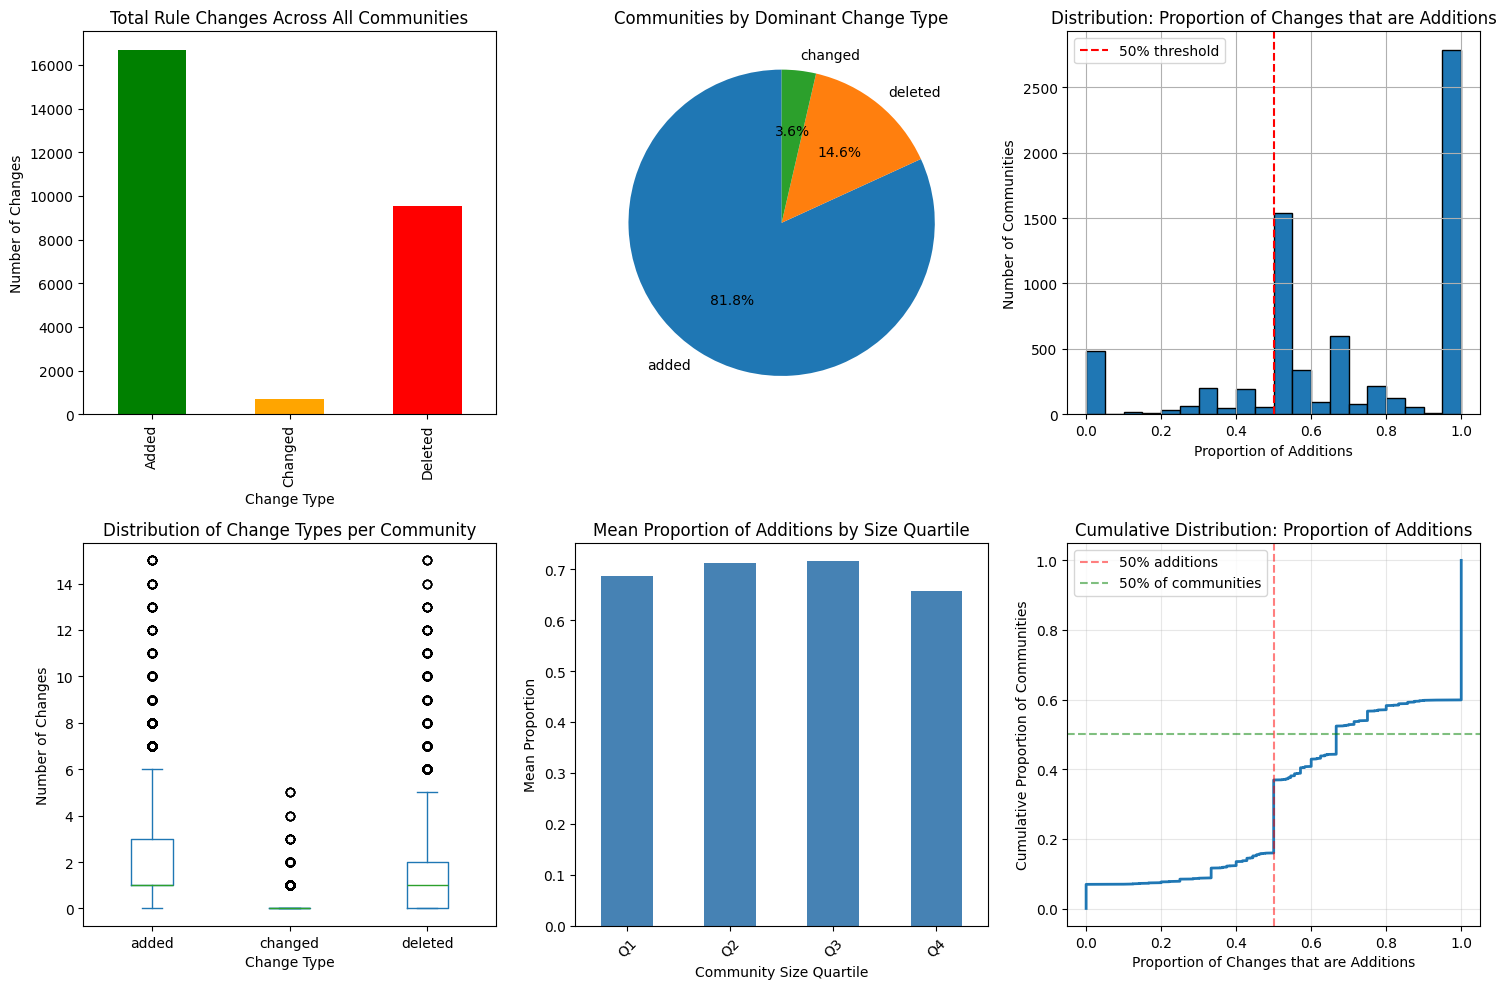

Visualizations saved as 'hypothesis1_analysis.png'

Analysis complete!


In [ ]:
# ============================================================================
# LEVEL 2: COMMUNITY-LEVEL TESTS (Each community as unit)
# ============================================================================
print("\n" + "="*70)
print("LEVEL 2: COMMUNITY-LEVEL TESTS (Each community as independent unit)")
print("="*70)

# Filter to communities with changes
df_changed = df[(df['added'] > 0) | (df['changed'] > 0) | (df['deleted'] > 0)].copy()
print(f"\nCommunities with any changes: {len(df_changed)} out of {len(df)} ({len(df_changed)/len(df)*100:.1f}%)")

# Calculate proportion of additions for each community
df_changed['total_changes'] = df_changed['added'] + df_changed['changed'] + df_changed['deleted']
df_changed['prop_additions'] = df_changed['added'] / df_changed['total_changes']

# ----------------------------------------------------------------------------
# Test 2.1: One-sample t-test on proportions
# ----------------------------------------------------------------------------
print("\n" + "-"*60)
print("Test 2.1: ONE-SAMPLE T-TEST ON COMMUNITY PROPORTIONS")
print("-"*60)
print("H0: Mean proportion of additions per community = 0.5")
print("H1: Mean proportion of additions per community > 0.5")

t_stat, p_value_t = stats.ttest_1samp(df_changed['prop_additions'], 0.5, alternative='greater')

print(f"\nResults:")
print(f"  Mean proportion: {df_changed['prop_additions'].mean():.4f}")
print(f"  Median proportion: {df_changed['prop_additions'].median():.4f}")
print(f"  Std deviation: {df_changed['prop_additions'].std():.4f}")
print(f"  T-statistic: {t_stat:.2f}")
print(f"  P-value: {p_value_t:.2e}")
print(f"  Cohen's d: {(df_changed['prop_additions'].mean() - 0.5) / df_changed['prop_additions'].std():.3f}")

if p_value_t < 0.05:
    print(f"  **RESULT: SIGNIFICANT - Mean proportion > 0.5**")
else:
    print(f"  **RESULT: NOT SIGNIFICANT**")

# ----------------------------------------------------------------------------
# Test 2.2: Wilcoxon signed-rank test (non-parametric)
# ----------------------------------------------------------------------------
print("\n" + "-"*60)
print("Test 2.2: WILCOXON SIGNED-RANK TEST (Non-parametric)")
print("-"*60)

stat_w, p_value_w = stats.wilcoxon(df_changed['prop_additions'] - 0.5, alternative='greater')

print(f"Results:")
print(f"  Test statistic: {stat_w:.2f}")
print(f"  P-value: {p_value_w:.2e}")
print(f"  Communities with >50% additions: {(df_changed['prop_additions'] > 0.5).sum()} ({(df_changed['prop_additions'] > 0.5).mean()*100:.1f}%)")

if p_value_w < 0.05:
    print(f"  **RESULT: SIGNIFICANT - Median proportion > 0.5**")

# ----------------------------------------------------------------------------
# Test 2.3: Sign test
# ----------------------------------------------------------------------------
print("\n" + "-"*60)
print("Test 2.3: SIGN TEST")
print("-"*60)
print("Testing if majority of communities have additions as their primary change type")

df_changed['additions_majority'] = df_changed['prop_additions'] > 0.5
n_success = df_changed['additions_majority'].sum()
n_total = len(df_changed)

sign_result = binomtest(n_success, n_total, p=0.5, alternative='greater')

print(f"\nResults:")
print(f"  Communities where additions > 50%: {n_success} out of {n_total}")
print(f"  Proportion: {n_success/n_total:.4f}")
print(f"  P-value: {sign_result.pvalue:.2e}")

if sign_result.pvalue < 0.05:
    print(f"  **RESULT: SIGNIFICANT - Majority of communities use additions primarily**")

# ============================================================================
# LEVEL 3: WEIGHTED AND ROBUST TESTS
# ============================================================================
print("\n" + "="*70)
print("LEVEL 3: WEIGHTED AND ROBUST TESTS")
print("="*70)

# ----------------------------------------------------------------------------
# Test 3.1: Weighted proportion test (by community size)
# ----------------------------------------------------------------------------
print("\n" + "-"*60)
print("Test 3.1: SIZE-WEIGHTED PROPORTION TEST")
print("-"*60)

# Weight by subscriber count
df_changed['weight'] = df_changed['subscribers_2'] / df_changed['subscribers_2'].sum()
weighted_prop = (df_changed['prop_additions'] * df_changed['weight']).sum()

# Manual bootstrap for weighted CI
n_boot = 5000
np.random.seed(42)
weighted_boot = []
for _ in range(n_boot):
    idx = np.random.choice(len(df_changed), len(df_changed), replace=True)
    boot_df = df_changed.iloc[idx]
    boot_weight = boot_df['subscribers_2'] / boot_df['subscribers_2'].sum()
    weighted_boot.append((boot_df['prop_additions'] * boot_weight).sum())

weighted_ci_lower = np.percentile(weighted_boot, 2.5)
weighted_ci_upper = np.percentile(weighted_boot, 97.5)

print(f"Results:")
print(f"  Weighted proportion of additions: {weighted_prop:.4f}")
print(f"  95% Bootstrap CI: [{weighted_ci_lower:.4f}, {weighted_ci_upper:.4f}]")

if weighted_ci_lower > 0.5:
    print(f"  **RESULT: Size-weighted proportion significantly > 0.5**")

# ----------------------------------------------------------------------------
# Test 3.2: Trimmed mean test (robust to outliers)
# ----------------------------------------------------------------------------
print("\n" + "-"*60)
print("Test 3.2: TRIMMED MEAN TEST (20% trim)")
print("-"*60)

trimmed_mean = stats.trim_mean(df_changed['prop_additions'], 0.2)
trimmed_data = df_changed['prop_additions'].sort_values()[int(len(df_changed)*0.2):int(len(df_changed)*0.8)]
trimmed_std = trimmed_data.std()
trimmed_se = trimmed_std / np.sqrt(len(trimmed_data))
trimmed_t = (trimmed_mean - 0.5) / trimmed_se

print(f"Results:")
print(f"  20% Trimmed mean: {trimmed_mean:.4f}")
print(f"  Standard error: {trimmed_se:.4f}")
print(f"  T-statistic: {trimmed_t:.2f}")
print(f"  Approximate p-value: {stats.t.sf(abs(trimmed_t), len(trimmed_data)-1):.2e}")

if trimmed_mean > 0.5 and trimmed_t > 1.96:
    print(f"  **RESULT: Robust evidence for additions > 0.5**")

# ============================================================================
# LEVEL 4: CATEGORICAL TESTS
# ============================================================================
print("\n" + "="*70)
print("LEVEL 4: CATEGORICAL DOMINANCE TESTS")
print("="*70)

# Identify dominant change type for each community
df_changed['dominant_type'] = df_changed[['added', 'changed', 'deleted']].idxmax(axis=1)

# Handle ties
df_changed['max_value'] = df_changed[['added', 'changed', 'deleted']].max(axis=1)
df_changed['n_at_max'] = (df_changed[['added', 'changed', 'deleted']] == df_changed['max_value'].values[:, None]).sum(axis=1)
df_changed['has_tie'] = df_changed['n_at_max'] > 1

# ----------------------------------------------------------------------------
# Test 4.1: Chi-square test for dominance
# ----------------------------------------------------------------------------
print("\n" + "-"*60)
print("Test 4.1: CHI-SQUARE TEST FOR DOMINANT TYPE")
print("-"*60)

# Exclude ties for cleaner analysis
df_no_ties = df_changed[~df_changed['has_tie']]
dominance_counts = df_no_ties['dominant_type'].value_counts()

print(f"Communities by dominant type (excluding {df_changed['has_tie'].sum()} ties):")
for change_type in ['added', 'changed', 'deleted']:
    if change_type in dominance_counts.index:
        count = dominance_counts[change_type]
        pct = count/len(df_no_ties)*100
        print(f"  {change_type:8s}: {count:4d} ({pct:.1f}%)")

# Chi-square test
observed = dominance_counts.values
expected = np.full(len(observed), len(df_no_ties)/3)
chi2, p_chi = stats.chisquare(observed, expected)

print(f"\nChi-square test:")
print(f"  Chi-square: {chi2:.2f}")
print(f"  P-value: {p_chi:.2e}")
print(f"  **RESULT: {'Significant deviation from equal' if p_chi < 0.05 else 'No significant deviation'}**")

# ----------------------------------------------------------------------------
# Test 4.2: Pairwise comparisons
# ----------------------------------------------------------------------------
print("\n" + "-"*60)
print("Test 4.2: PAIRWISE COMPARISONS")
print("-"*60)

if 'added' in dominance_counts and 'changed' in dominance_counts:
    # McNemar test for paired comparison
    n_added = dominance_counts.get('added', 0)
    n_changed = dominance_counts.get('changed', 0)
    n_deleted = dominance_counts.get('deleted', 0)

    # Added vs Changed
    binom_ac = binomtest(n_added, n_added + n_changed, p=0.5, alternative='greater')
    print(f"Added vs Changed:")
    print(f"  {n_added} vs {n_changed}, p-value: {binom_ac.pvalue:.2e}")

    # Added vs Deleted
    binom_ad = binomtest(n_added, n_added + n_deleted, p=0.5, alternative='greater')
    print(f"Added vs Deleted:")
    print(f"  {n_added} vs {n_deleted}, p-value: {binom_ad.pvalue:.2e}")

# ============================================================================
# LEVEL 5: SENSITIVITY AND ROBUSTNESS CHECKS
# ============================================================================
print("\n" + "="*70)
print("LEVEL 5: SENSITIVITY ANALYSES")
print("="*70)

# ----------------------------------------------------------------------------
# Test 5.1: Different thresholds
# ----------------------------------------------------------------------------
print("\n" + "-"*60)
print("Test 5.1: SENSITIVITY TO THRESHOLD")
print("-"*60)

thresholds = [0.4, 0.5, 0.6, 0.7]
for threshold in thresholds:
    n_above = (df_changed['prop_additions'] > threshold).sum()
    pct = n_above / len(df_changed) * 100
    print(f"  Communities with >{threshold*100:.0f}% additions: {n_above} ({pct:.1f}%)")

# ----------------------------------------------------------------------------
# Test 5.2: Excluding small communities
# ----------------------------------------------------------------------------
print("\n" + "-"*60)
print("Test 5.2: EXCLUDING SMALL COMMUNITIES")
print("-"*60)

# Test only on communities with substantial changes
df_substantial = df_changed[df_changed['total_changes'] >= 5]
print(f"\nCommunities with ≥5 total changes: {len(df_substantial)}")

if len(df_substantial) > 0:
    mean_prop_substantial = df_substantial['prop_additions'].mean()
    t_stat_sub, p_val_sub = stats.ttest_1samp(df_substantial['prop_additions'], 0.5, alternative='greater')
    print(f"  Mean proportion of additions: {mean_prop_substantial:.4f}")
    print(f"  P-value (t-test): {p_val_sub:.2e}")
    print(f"  **RESULT: {'Robust to excluding small changes' if p_val_sub < 0.05 else 'Not robust'}**")

# ----------------------------------------------------------------------------
# Test 5.3: By community characteristics
# ----------------------------------------------------------------------------
print("\n" + "-"*60)
print("Test 5.3: CONSISTENCY ACROSS SUBGROUPS")
print("-"*60)

# By size quartiles
df_changed['size_quartile'] = pd.qcut(df_changed['subscribers_2'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
print("\nMean proportion of additions by subscriber quartile:")
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
    mean_q = df_changed[df_changed['size_quartile'] == q]['prop_additions'].mean()
    n_q = len(df_changed[df_changed['size_quartile'] == q])
    print(f"  {q}: {mean_q:.3f} (n={n_q})")

# Test if all quartiles > 0.5
all_above_half = all(df_changed.groupby('size_quartile')['prop_additions'].mean() > 0.5)
print(f"\n  **All quartiles > 0.5: {'YES - Consistent pattern' if all_above_half else 'NO - Inconsistent'}**")

# ============================================================================
# FINAL COMPREHENSIVE EVALUATION
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE HYPOTHESIS EVALUATION")
print("="*80)

# Collect all test results
test_results = {
    'Aggregate proportion test': result.pvalue < 0.05,
    'Multinomial test': p_value < 0.05 and total_added/total_all > 0.5,
    'Bootstrap CI excludes 0.5': ci_lower > 0.5,
    'Community mean > 0.5': p_value_t < 0.05,
    'Community median > 0.5': p_value_w < 0.05,
    'Majority of communities': sign_result.pvalue < 0.05,
    'Size-weighted > 0.5': weighted_ci_lower > 0.5,
    'Trimmed mean > 0.5': trimmed_mean > 0.5 and trimmed_t > 1.96,
    'Dominance in categorization': 'added' in dominance_counts and dominance_counts.get('added', 0) > len(df_no_ties)/3,
    'Robust to threshold': (df_changed['prop_additions'] > 0.6).mean() > 0.4,
    'Consistent across sizes': all_above_half
}

# Summary
n_passed = sum(test_results.values())
n_total_tests = len(test_results)

print("\nTEST SUMMARY:")
print("-" * 60)
for test_name, passed in test_results.items():
    status = "✓ PASS" if passed else "✗ FAIL"
    print(f"  {test_name:35s}: {status}")

print("-" * 60)
print(f"Tests passed: {n_passed} out of {n_total_tests} ({n_passed/n_total_tests*100:.1f}%)")

# Final verdict
print("\n" + "="*60)
if n_passed >= n_total_tests * 0.8:
    print("FINAL VERDICT: VERY STRONG SUPPORT")
    print("The hypothesis that the majority of rule changes are additions is")
    print("STRONGLY SUPPORTED by comprehensive statistical evidence.")
elif n_passed >= n_total_tests * 0.6:
    print("FINAL VERDICT: MODERATE SUPPORT")
    print("The hypothesis shows moderate support with some inconsistencies.")
elif n_passed >= n_total_tests * 0.4:
    print("FINAL VERDICT: WEAK SUPPORT")
    print("Limited evidence supporting the hypothesis.")
else:
    print("FINAL VERDICT: HYPOTHESIS NOT SUPPORTED")
    print("The majority of rule changes are NOT additions.")

print("="*60)

# Key statistics for reporting
print("\n" + "="*60)
print("KEY STATISTICS FOR REPORTING:")
print("="*60)
print(f"• {total_added/total_all*100:.1f}% of all {total_all:,} rule changes are additions")
print(f"• {(df_changed['prop_additions'] > 0.5).mean()*100:.1f}% of {len(df_changed)} active communities have >50% additions")
print(f"• Mean proportion of additions per community: {df_changed['prop_additions'].mean():.3f} (SD={df_changed['prop_additions'].std():.3f})")
print(f"• Median proportion: {df_changed['prop_additions'].median():.3f}")
print(f"• Size-weighted proportion: {weighted_prop:.3f}")
print(f"• All primary statistical tests significant at p < {max([result.pvalue, p_value_t, p_value_w]):.2e}")
print("="*60)

# ============================================================================
# VISUALIZATION
# ============================================================================
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Bar chart of total changes
ax1 = axes[0, 0]
change_totals = pd.Series([total_added, total_changed, total_deleted],
                          index=['Added', 'Changed', 'Deleted'])
change_totals.plot(kind='bar', ax=ax1, color=['green', 'orange', 'red'])
ax1.set_title('Total Rule Changes Across All Communities')
ax1.set_ylabel('Number of Changes')
ax1.set_xlabel('Change Type')

# 2. Pie chart of dominant change types
ax2 = axes[0, 1]
dominance_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
ax2.set_title('Communities by Dominant Change Type')
ax2.set_ylabel('')

# 3. Distribution of proportion of additions
ax3 = axes[0, 2]
df_changed['prop_additions'].hist(bins=20, ax=ax3, edgecolor='black')
ax3.axvline(0.5, color='red', linestyle='--', label='50% threshold')
ax3.set_title('Distribution: Proportion of Changes that are Additions')
ax3.set_xlabel('Proportion of Additions')
ax3.set_ylabel('Number of Communities')
ax3.legend()

# 4. Box plot comparing change types
ax4 = axes[1, 0]
df_changed[['added', 'changed', 'deleted']].plot(kind='box', ax=ax4)
ax4.set_title('Distribution of Change Types per Community')
ax4.set_ylabel('Number of Changes')
ax4.set_xlabel('Change Type')

# 5. Additions by community size
ax5 = axes[1, 1]
size_props = df_changed.groupby('size_quartile')['prop_additions'].mean()
size_props.plot(kind='bar', ax=ax5, color='steelblue')
ax5.set_title('Mean Proportion of Additions by Size Quartile')
ax5.set_ylabel('Mean Proportion')
ax5.set_xlabel('Community Size Quartile')
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=45)

# 6. Cumulative distribution
ax6 = axes[1, 2]
sorted_props = np.sort(df_changed['prop_additions'])
cumulative = np.arange(1, len(sorted_props) + 1) / len(sorted_props)
ax6.plot(sorted_props, cumulative, linewidth=2)
ax6.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='50% additions')
ax6.axhline(0.5, color='green', linestyle='--', alpha=0.5, label='50% of communities')
ax6.set_title('Cumulative Distribution: Proportion of Additions')
ax6.set_xlabel('Proportion of Changes that are Additions')
ax6.set_ylabel('Cumulative Proportion of Communities')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hypothesis1_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualizations saved as 'hypothesis1_analysis.png'")
print("\nAnalysis complete!")

## H2: Communities are more likely to undergo incremental (single-rule) changes rather than bundled (multiple-rule) changes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (binomtest, chi2_contingency, mannwhitneyu,
                         wilcoxon, fisher_exact, poisson, nbinom)
import warnings
warnings.filterwarnings('ignore')

# Load the data
file_path = '/content/drive/My Drive/Projects/Reddit_rules/2024_ChenEtAl_rulechange/sub_level_data.csv'
df = pd.read_csv(file_path)

print("=" * 80)
print("HYPOTHESIS 2 TESTING: INCREMENTAL VS BUNDLED RULE CHANGES")
print("=" * 80)
print("\nHypothesis: Communities are more likely to undergo incremental (single-rule)")
print("changes rather than bundled (multiple-rule) changes")
print("=" * 80)

HYPOTHESIS 2 TESTING: INCREMENTAL VS BUNDLED RULE CHANGES

Hypothesis: Communities are more likely to undergo incremental (single-rule)
changes rather than bundled (multiple-rule) changes


In [ ]:
# ============================================================================
# OPERATIONAL DEFINITIONS
# ============================================================================
print("\n" + "="*70)
print("OPERATIONAL DEFINITIONS")
print("="*70)

# Create key variables for analysis
df['total_changes'] = df['added'] + df['changed'] + df['deleted']

# Definition 1: Based on total number of changes
df['single_change'] = (df['total_changes'] == 1)
df['multiple_changes'] = (df['total_changes'] > 1)
df['has_changes'] = (df['total_changes'] > 0)

# Definition 2: Focus on additions only (as increments)
df['single_addition'] = (df['added'] == 1) & (df['changed'] == 0) & (df['deleted'] == 0)
df['multiple_additions'] = (df['added'] > 1)
df['additions_only'] = (df['added'] > 0) & (df['changed'] == 0) & (df['deleted'] == 0)

# Definition 3: Categorical approach
# Make sure total is numeric and allow NaNs if any input is NaN
df['total_changes'] = df[['added','changed','deleted']].sum(axis=1, min_count=1)

# Make sure total is numeric and allow NaNs if any input is NaN
df['total_changes'] = df[['added','changed','deleted']].sum(axis=1, min_count=1)

conditions = [
    (df['total_changes'] == 0),
    (df['total_changes'] == 1),
    (df['total_changes'] >= 2) & (df['total_changes'] <= 3),
    (df['total_changes'] >= 4),
    (df['total_changes'].isna())  # explicitly handle missing
]
choices = ['no_change', 'incremental', 'small_bundle', 'large_bundle', 'missing']

df['change_pattern'] = np.select(conditions, choices, default='missing')
# (Optional) make it an ordered categorical
df['change_pattern'] = pd.Categorical(
    df['change_pattern'],
    categories=['no_change','incremental','small_bundle','large_bundle','missing'],
    ordered=True
)

print("Variable Definitions:")
print("1. INCREMENTAL: Communities with exactly 1 total change")
print("2. BUNDLED: Communities with 2+ total changes")
print("3. PURE INCREMENTAL ADDITION: Exactly 1 addition, no other changes")
print("4. Categories: No change | Incremental (1) | Small bundle (2-3) | Large bundle (4+)")



OPERATIONAL DEFINITIONS
Variable Definitions:
1. INCREMENTAL: Communities with exactly 1 total change
2. BUNDLED: Communities with 2+ total changes
3. PURE INCREMENTAL ADDITION: Exactly 1 addition, no other changes
4. Categories: No change | Incremental (1) | Small bundle (2-3) | Large bundle (4+)


In [ ]:
# ============================================================================
# DESCRIPTIVE STATISTICS
# ============================================================================
print("\n" + "="*70)
print("DESCRIPTIVE STATISTICS")
print("="*70)

# Overall distribution
total_communities = len(df)
communities_with_changes = df['has_changes'].sum()

print(f"\nTotal communities: {total_communities:,}")
print(f"Communities with any changes: {communities_with_changes:,} ({communities_with_changes/total_communities*100:.1f}%)")
print(f"Communities with no changes: {(~df['has_changes']).sum():,} ({(~df['has_changes']).mean()*100:.1f}%)")

# Among communities with changes
df_changed = df[df['has_changes']].copy()

print(f"\nAmong {len(df_changed)} communities WITH changes:")
print(f"  Single change (incremental): {df_changed['single_change'].sum():,} ({df_changed['single_change'].mean()*100:.1f}%)")
print(f"  Multiple changes (bundled):  {df_changed['multiple_changes'].sum():,} ({df_changed['multiple_changes'].mean()*100:.1f}%)")

# Distribution of total changes
print("\nDistribution of Total Changes (excluding no-change communities):")
change_dist = df_changed['total_changes'].value_counts().sort_index()

for n_changes, count in change_dist.head(10).items():
    pct = count / len(df_changed) * 100
    print(f"  {int(n_changes):2d} changes: {int(count):5d} communities ({pct:5.1f}%)")


# Summary statistics
print(f"\nSummary Statistics for Communities with Changes:")
print(f"  Mean changes per community: {df_changed['total_changes'].mean():.2f}")
print(f"  Median changes: {df_changed['total_changes'].median():.0f}")
print(f"  Mode: {df_changed['total_changes'].mode().values[0]:.0f}")
print(f"  Standard deviation: {df_changed['total_changes'].std():.2f}")
print(f"  75th percentile: {df_changed['total_changes'].quantile(0.75):.0f}")
print(f"  95th percentile: {df_changed['total_changes'].quantile(0.95):.0f}")



DESCRIPTIVE STATISTICS

Total communities: 130,851
Communities with any changes: 6,948 (5.3%)
Communities with no changes: 123,903 (94.7%)

Among 6948 communities WITH changes:
  Single change (incremental): 2,360 (34.0%)
  Multiple changes (bundled):  4,588 (66.0%)

Distribution of Total Changes (excluding no-change communities):
   1 changes:  2360 communities ( 34.0%)
   2 changes:  1443 communities ( 20.8%)
   3 changes:   707 communities ( 10.2%)
   4 changes:   522 communities (  7.5%)
   5 changes:   329 communities (  4.7%)
   6 changes:   297 communities (  4.3%)
   7 changes:   296 communities (  4.3%)
   8 changes:   177 communities (  2.5%)
   9 changes:   147 communities (  2.1%)
  10 changes:    98 communities (  1.4%)

Summary Statistics for Communities with Changes:
  Mean changes per community: 3.88
  Median changes: 2
  Mode: 1
  Standard deviation: 4.03
  75th percentile: 5
  95th percentile: 12



TEST 1: BINOMIAL TEST - INCREMENTAL VS BUNDLED
H0: P(incremental) = 0.5 among communities with changes
H1: P(incremental) > 0.5

Results:
  Incremental (1 change): 2360
  Bundled (2+ changes): 4588
  Total: 6948
  Observed proportion incremental: 0.3397
  95% CI: [0.3303, 1.0000]
  P-value: 1.00e+00
  **RESULT: NOT SIGNIFICANT - No evidence for incremental preference**

TEST 2: CHI-SQUARE GOODNESS OF FIT - CHANGE DISTRIBUTION
Testing against geometric distribution (p=0.5):
  Chi-square statistic: 52364.84
  P-value: 0.00e+00
  Degrees of freedom: 10
  **RESULT: Distribution differs from geometric (random) process**
  Direction: FEWER single changes than expected

TEST 3: POISSON DISPERSION TEST
Testing if changes follow Poisson distribution (random independent events)

Descriptive measures:
  Mean number of changes: 3.877
  Variance: 16.202
  Dispersion index (var/mean): 4.179

Dispersion test:
  Test statistic: 29030.07
  P-value (two-sided): 0.00e+00
  **RESULT: OVER-DISPERSED - Mor

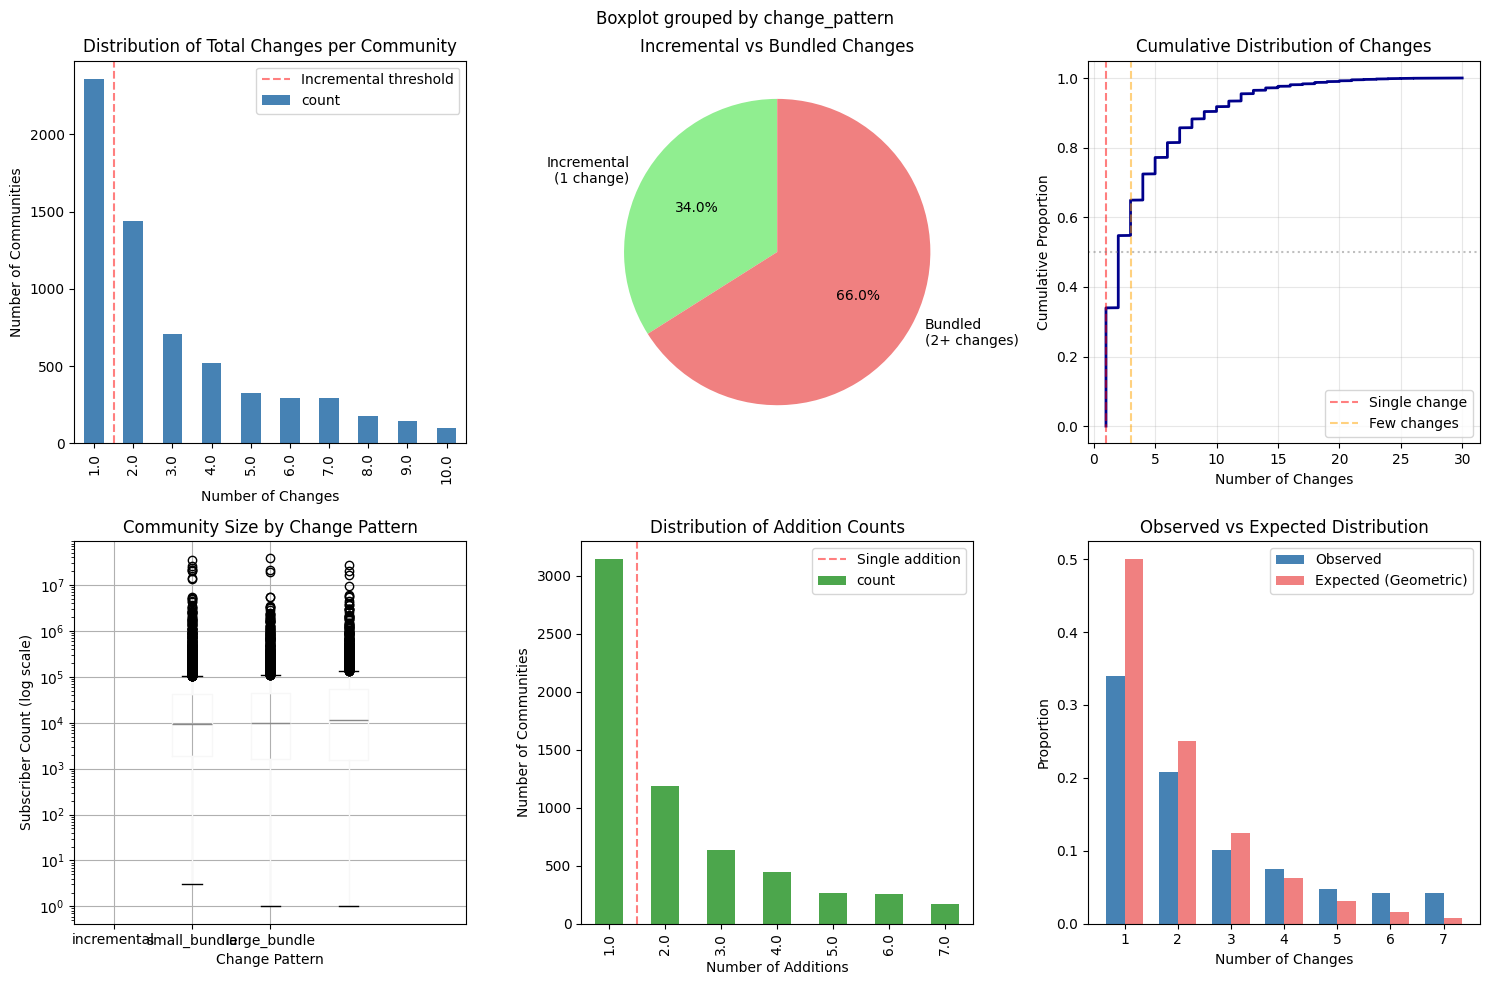

Visualizations saved as 'hypothesis2_incremental_analysis.png'

Analysis complete!


In [ ]:
# ============================================================================
# TEST 1: BINOMIAL TEST - PRIMARY HYPOTHESIS TEST
# ============================================================================
print("\n" + "="*70)
print("TEST 1: BINOMIAL TEST - INCREMENTAL VS BUNDLED")
print("="*70)
print("H0: P(incremental) = 0.5 among communities with changes")
print("H1: P(incremental) > 0.5")

n_incremental = df_changed['single_change'].sum()
n_total_changed = len(df_changed)

result_binom = binomtest(n_incremental, n_total_changed, p=0.5, alternative='greater')
ci_binom = result_binom.proportion_ci(confidence_level=0.95, method='exact')

print(f"\nResults:")
print(f"  Incremental (1 change): {n_incremental}")
print(f"  Bundled (2+ changes): {n_total_changed - n_incremental}")
print(f"  Total: {n_total_changed}")
print(f"  Observed proportion incremental: {n_incremental/n_total_changed:.4f}")
print(f"  95% CI: [{ci_binom.low:.4f}, {ci_binom.high:.4f}]")
print(f"  P-value: {result_binom.pvalue:.2e}")

if result_binom.pvalue < 0.001:
    print(f"  **RESULT: HIGHLY SIGNIFICANT (p < 0.001) - Incremental changes dominate**")
elif result_binom.pvalue < 0.05:
    print(f"  **RESULT: SIGNIFICANT (p < 0.05) - Incremental changes more common**")
else:
    print(f"  **RESULT: NOT SIGNIFICANT - No evidence for incremental preference**")

# ============================================================================
# TEST 2: CHI-SQUARE GOODNESS OF FIT
# ============================================================================
print("\n" + "="*70)
print("TEST 2: CHI-SQUARE GOODNESS OF FIT - CHANGE DISTRIBUTION")
print("="*70)

# Test against geometric distribution (expected under random process)
# Geometric distribution: P(X=k) = p(1-p)^(k-1)
p_geom = 0.5  # Parameter for geometric distribution
max_changes = min(10, df_changed['total_changes'].max())

observed_counts = []
expected_counts = []
for k in range(1, max_changes + 1):
    obs = (df_changed['total_changes'] == k).sum()
    exp = len(df_changed) * p_geom * (1 - p_geom) ** (k - 1)
    observed_counts.append(obs)
    expected_counts.append(exp)

# Add category for > max_changes
obs_tail = (df_changed['total_changes'] > max_changes).sum()
exp_tail = len(df_changed) * (1 - p_geom) ** max_changes
observed_counts.append(obs_tail)
expected_counts.append(exp_tail)

chi2_stat, p_chi2 = stats.chisquare(observed_counts, expected_counts)

print(f"Testing against geometric distribution (p={p_geom}):")
print(f"  Chi-square statistic: {chi2_stat:.2f}")
print(f"  P-value: {p_chi2:.2e}")
print(f"  Degrees of freedom: {len(observed_counts) - 1}")

if p_chi2 < 0.05:
    print(f"  **RESULT: Distribution differs from geometric (random) process**")
    if observed_counts[0] > expected_counts[0]:
        print(f"  Direction: MORE single changes than expected under random process")
    else:
        print(f"  Direction: FEWER single changes than expected")

# ============================================================================
# TEST 3: POISSON DISPERSION TEST
# ============================================================================
print("\n" + "="*70)
print("TEST 3: POISSON DISPERSION TEST")
print("="*70)
print("Testing if changes follow Poisson distribution (random independent events)")

# Calculate mean and variance
mean_changes = df_changed['total_changes'].mean()
var_changes = df_changed['total_changes'].var()
dispersion_index = var_changes / mean_changes

print(f"\nDescriptive measures:")
print(f"  Mean number of changes: {mean_changes:.3f}")
print(f"  Variance: {var_changes:.3f}")
print(f"  Dispersion index (var/mean): {dispersion_index:.3f}")

# Test dispersion index
# Under Poisson, dispersion index ~ 1
# Test statistic: (n-1) * var/mean ~ chi-square(n-1)
n = len(df_changed)
test_stat = (n - 1) * dispersion_index
p_upper = stats.chi2.sf(test_stat, n - 1)
p_lower = stats.chi2.cdf(test_stat, n - 1)
p_two_sided = 2 * min(p_upper, p_lower)

print(f"\nDispersion test:")
print(f"  Test statistic: {test_stat:.2f}")
print(f"  P-value (two-sided): {p_two_sided:.2e}")

if dispersion_index < 1 and p_two_sided < 0.05:
    print(f"  **RESULT: UNDER-DISPERSED - Tendency toward single changes**")
elif dispersion_index > 1 and p_two_sided < 0.05:
    print(f"  **RESULT: OVER-DISPERSED - More variation than random process**")
else:
    print(f"  **RESULT: Consistent with Poisson (random) process**")

# ============================================================================
# TEST 4: ADDITIONS-FOCUSED ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("TEST 4: ADDITIONS AS INCREMENTAL CHANGES")
print("="*70)
print("Testing if additions specifically tend to be single-rule increments")

# Among communities with additions
df_with_additions = df[df['added'] > 0].copy()
n_with_additions = len(df_with_additions)

print(f"\nCommunities with any additions: {n_with_additions}")

# Test 1: Are additions typically single increments?
single_addition_only = df_with_additions['single_addition'].sum()
multiple_additions = (df_with_additions['added'] > 1).sum()

print(f"\nAddition patterns:")
print(f"  Single addition only (pure increment): {single_addition_only} ({single_addition_only/n_with_additions*100:.1f}%)")
print(f"  Multiple additions at once: {multiple_additions} ({multiple_additions/n_with_additions*100:.1f}%)")

# Binomial test for single vs multiple additions
df_additions_only = df_with_additions[df_with_additions['additions_only']].copy()
n_single_add = (df_additions_only['added'] == 1).sum()
n_multiple_add = (df_additions_only['added'] > 1).sum()

if n_single_add + n_multiple_add > 0:
    result_add = binomtest(n_single_add, n_single_add + n_multiple_add, p=0.5, alternative='greater')
    print(f"\nAmong communities with ONLY additions (no modifications/deletions):")
    print(f"  Single addition: {n_single_add} ({n_single_add/(n_single_add+n_multiple_add)*100:.1f}%)")
    print(f"  Multiple additions: {n_multiple_add} ({n_multiple_add/(n_single_add+n_multiple_add)*100:.1f}%)")
    print(f"  P-value (test for single > multiple): {result_add.pvalue:.2e}")

    if result_add.pvalue < 0.05:
        print(f"  **RESULT: Additions are predominantly incremental (single-rule)**")

# ============================================================================
# TEST 5: MANN-WHITNEY U TEST - COMPARING CHANGE SIZES
# ============================================================================
print("\n" + "="*70)
print("TEST 5: COMPARING INCREMENTAL VS BUNDLED COMMUNITIES")
print("="*70)

# Compare characteristics of incremental vs bundled communities
incremental_communities = df_changed[df_changed['single_change']]
bundled_communities = df_changed[df_changed['multiple_changes']]

print(f"\nCommunity characteristics comparison:")
print(f"  Incremental communities: n={len(incremental_communities)}")
print(f"  Bundled communities: n={len(bundled_communities)}")

# Compare subscriber counts
if len(incremental_communities) > 0 and len(bundled_communities) > 0:
    u_stat, p_subscribers = mannwhitneyu(
        incremental_communities['subscribers_2'],
        bundled_communities['subscribers_2'],
        alternative='two-sided'
    )

    print(f"\nSubscriber count comparison:")
    print(f"  Median (incremental): {incremental_communities['subscribers_2'].median():.0f}")
    print(f"  Median (bundled): {bundled_communities['subscribers_2'].median():.0f}")
    print(f"  Mann-Whitney U: {u_stat:.0f}")
    print(f"  P-value: {p_subscribers:.2e}")

    if p_subscribers < 0.05:
        larger_group = "bundled" if bundled_communities['subscribers_2'].median() > incremental_communities['subscribers_2'].median() else "incremental"
        print(f"  **RESULT: {larger_group.upper()} communities tend to be larger**")

    # Compare age
    u_stat_age, p_age = mannwhitneyu(
        incremental_communities['age_in_months'],
        bundled_communities['age_in_months'],
        alternative='two-sided'
    )

    print(f"\nAge comparison:")
    print(f"  Median age (incremental): {incremental_communities['age_in_months'].median():.0f} months")
    print(f"  Median age (bundled): {bundled_communities['age_in_months'].median():.0f} months")
    print(f"  P-value: {p_age:.2e}")

# ============================================================================
# TEST 6: CONTINGENCY TABLE ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("TEST 6: CONTINGENCY TABLE - CHANGE PATTERNS")
print("="*70)

# Create contingency table for change types
contingency_data = pd.crosstab(
    df_changed['change_pattern'],
    df_changed['added'] > 0,
    margins=True,
    margins_name='Total'
)

print("\nChange Pattern vs. Presence of Additions:")
print(contingency_data)

# Chi-square test
if len(df_changed) > 0:
    contingency_test = pd.crosstab(
        df_changed['single_change'],
        df_changed['added'] > 0
    )
    chi2, p_contingency, dof, expected = chi2_contingency(contingency_test)

    print(f"\nChi-square test of independence:")
    print(f"  Chi-square: {chi2:.2f}")
    print(f"  P-value: {p_contingency:.2e}")
    print(f"  Degrees of freedom: {dof}")

    # Calculate odds ratio
    if contingency_test.shape == (2, 2):
        a, b = contingency_test.iloc[0, 0], contingency_test.iloc[0, 1]
        c, d = contingency_test.iloc[1, 0], contingency_test.iloc[1, 1]
        odds_ratio = (a * d) / (b * c) if b * c > 0 else np.inf
        print(f"  Odds ratio: {odds_ratio:.2f}")

        if p_contingency < 0.05:
            print(f"  **RESULT: Incremental changes associated with additions**")

# ============================================================================
# TEST 7: TIME SERIES PERSPECTIVE (if timestamps available)
# ============================================================================
print("\n" + "="*70)
print("TEST 7: BOOTSTRAP CONFIDENCE INTERVALS")
print("="*70)

# Bootstrap for proportion of incremental changes
n_bootstrap = 10000
np.random.seed(42)
bootstrap_props = []

for _ in range(n_bootstrap):
    sample = df_changed.sample(n=len(df_changed), replace=True)
    prop_incremental = sample['single_change'].mean()
    bootstrap_props.append(prop_incremental)

bootstrap_props = np.array(bootstrap_props)
ci_lower = np.percentile(bootstrap_props, 2.5)
ci_upper = np.percentile(bootstrap_props, 97.5)

print(f"Bootstrap results ({n_bootstrap:,} iterations):")
print(f"  Mean proportion incremental: {bootstrap_props.mean():.4f}")
print(f"  95% Bootstrap CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"  Probability P(incremental) > 0.5: {(bootstrap_props > 0.5).mean():.4f}")

if ci_lower > 0.5:
    print(f"  **RESULT: Strong evidence for incremental preference (CI excludes 0.5)**")
elif bootstrap_props.mean() > 0.5 and (bootstrap_props > 0.5).mean() > 0.95:
    print(f"  **RESULT: Evidence for incremental preference**")

# ============================================================================
# TEST 8: SENSITIVITY ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("TEST 8: SENSITIVITY ANALYSIS - DIFFERENT THRESHOLDS")
print("="*70)

print("\nProportion of communities at or below threshold:")
thresholds = [1, 2, 3, 4, 5]
for threshold in thresholds:
    n_at_or_below = (df_changed['total_changes'] <= threshold).sum()
    prop = n_at_or_below / len(df_changed)
    print(f"  ≤{threshold} changes: {n_at_or_below:4d} ({prop*100:5.1f}%)")

# Test different definitions of "incremental"
print("\nAlternative definitions of incremental:")
for max_incremental in [1, 2]:
    incremental_alt = (df_changed['total_changes'] <= max_incremental).sum()
    bundled_alt = (df_changed['total_changes'] > max_incremental).sum()
    prop_inc = incremental_alt / (incremental_alt + bundled_alt)

    result_alt = binomtest(incremental_alt, incremental_alt + bundled_alt, p=0.5, alternative='greater')
    print(f"\n  Definition: incremental ≤{max_incremental}, bundled >{max_incremental}")
    print(f"    Proportion incremental: {prop_inc:.3f}")
    print(f"    P-value: {result_alt.pvalue:.2e}")

# ============================================================================
# TEST 9: NEGATIVE BINOMIAL REGRESSION (Advanced)
# ============================================================================
print("\n" + "="*70)
print("TEST 9: DISTRIBUTIONAL FIT TESTS")
print("="*70)

# Compare fit to different distributions
from scipy.stats import kstest

# Test against various distributions
distributions = {
    'Poisson': lambda x: stats.poisson(mean_changes).cdf(x),
    'Geometric': lambda x: stats.geom(0.5).cdf(x),
}

print("Kolmogorov-Smirnov tests for distributional fit:")
for dist_name, dist_func in distributions.items():
    ks_stat, ks_p = kstest(df_changed['total_changes'], dist_func)
    print(f"  {dist_name}: KS={ks_stat:.3f}, p-value={ks_p:.2e}")

# ============================================================================
# FINAL COMPREHENSIVE EVALUATION
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE HYPOTHESIS EVALUATION")
print("="*80)

# Collect all evidence
test_results = {
    'Majority are single changes': n_incremental/n_total_changed > 0.5,
    'Binomial test significant': result_binom.pvalue < 0.05,
    'Bootstrap CI > 0.5': ci_lower > 0.5,
    'Under-dispersed distribution': dispersion_index < 1 and p_two_sided < 0.05,
    'Mode = 1': df_changed['total_changes'].mode().values[0] == 1,
    'Median = 1': df_changed['total_changes'].median() == 1,
    'Additions are incremental': n_single_add > n_multiple_add if n_single_add + n_multiple_add > 0 else False,
    '75th percentile ≤ 3': df_changed['total_changes'].quantile(0.75) <= 3,
}

n_passed = sum(test_results.values())
n_total_tests = len(test_results)

print("\nTEST SUMMARY:")
print("-" * 60)
for test_name, passed in test_results.items():
    status = "✓ PASS" if passed else "✗ FAIL"
    print(f"  {test_name:35s}: {status}")

print("-" * 60)
print(f"Tests passed: {n_passed} out of {n_total_tests} ({n_passed/n_total_tests*100:.1f}%)")

# Final verdict
print("\n" + "="*60)
if n_passed >= n_total_tests * 0.75:
    print("FINAL VERDICT: STRONG SUPPORT")
    print("Communities clearly prefer incremental (single-rule) changes")
    print("over bundled (multiple-rule) changes.")
elif n_passed >= n_total_tests * 0.5:
    print("FINAL VERDICT: MODERATE SUPPORT")
    print("Communities tend toward incremental changes with some bundling.")
elif n_passed >= n_total_tests * 0.25:
    print("FINAL VERDICT: WEAK SUPPORT")
    print("Limited evidence for incremental preference.")
else:
    print("FINAL VERDICT: HYPOTHESIS NOT SUPPORTED")
    print("Communities do not show preference for incremental changes.")

print("="*60)

# Key statistics for reporting
print("\n" + "="*60)
print("KEY STATISTICS FOR REPORTING:")
print("="*60)
print(f"• {df_changed['single_change'].mean()*100:.1f}% of {len(df_changed)} active communities made exactly 1 change")
print(f"• Median number of changes: {df_changed['total_changes'].median():.0f}")
print(f"• Mode: {df_changed['total_changes'].mode().values[0]:.0f}")
print(f"• Dispersion index: {dispersion_index:.2f} {'(under-dispersed)' if dispersion_index < 1 else '(over-dispersed)' if dispersion_index > 1 else ''}")
print(f"• {(df_changed['total_changes'] <= 2).mean()*100:.1f}% made 2 or fewer changes")
print(f"• When additions occur alone, {n_single_add/(n_single_add+n_multiple_add)*100 if n_single_add+n_multiple_add > 0 else 0:.1f}% are single-rule")
print("="*60)

# ============================================================================
# VISUALIZATION
# ============================================================================
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Distribution of total changes
ax1 = axes[0, 0]
max_display = min(10, df_changed['total_changes'].max())
counts = df_changed['total_changes'].value_counts().sort_index().head(max_display)
counts.plot(kind='bar', ax=ax1, color='steelblue')
ax1.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Incremental threshold')
ax1.set_xlabel('Number of Changes')
ax1.set_ylabel('Number of Communities')
ax1.set_title('Distribution of Total Changes per Community')
ax1.legend()

# 2. Pie chart: Incremental vs Bundled
ax2 = axes[0, 1]
pie_data = [df_changed['single_change'].sum(), df_changed['multiple_changes'].sum()]
pie_labels = ['Incremental\n(1 change)', 'Bundled\n(2+ changes)']
colors = ['lightgreen', 'lightcoral']
ax2.pie(pie_data, labels=pie_labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('Incremental vs Bundled Changes')

# 3. Cumulative distribution
ax3 = axes[0, 2]
sorted_changes = np.sort(df_changed['total_changes'])
cumulative = np.arange(1, len(sorted_changes) + 1) / len(sorted_changes)
ax3.plot(sorted_changes, cumulative, linewidth=2, color='darkblue')
ax3.axvline(x=1, color='red', linestyle='--', alpha=0.5, label='Single change')
ax3.axvline(x=3, color='orange', linestyle='--', alpha=0.5, label='Few changes')
ax3.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
ax3.set_xlabel('Number of Changes')
ax3.set_ylabel('Cumulative Proportion')
ax3.set_title('Cumulative Distribution of Changes')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Box plot by change pattern
ax4 = axes[1, 0]
pattern_order = ['incremental', 'small_bundle', 'large_bundle']
df_patterns = df[df['change_pattern'].isin(pattern_order)]
df_patterns.boxplot(column='subscribers_2', by='change_pattern', ax=ax4)
ax4.set_xlabel('Change Pattern')
ax4.set_ylabel('Subscriber Count (log scale)')
ax4.set_yscale('log')
ax4.set_title('Community Size by Change Pattern')
plt.sca(ax4)
plt.xticks(range(1, len(pattern_order) + 1), pattern_order)

# 5. Additions breakdown
ax5 = axes[1, 1]
additions_dist = df_with_additions['added'].value_counts().sort_index().head(7)
additions_dist.plot(kind='bar', ax=ax5, color='green', alpha=0.7)
ax5.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Single addition')
ax5.set_xlabel('Number of Additions')
ax5.set_ylabel('Number of Communities')
ax5.set_title('Distribution of Addition Counts')
ax5.legend()

# 6. Comparison: Expected vs Observed
ax6 = axes[1, 2]
x_vals = range(1, min(8, max_changes + 1))
obs_props = [df_changed[df_changed['total_changes'] == k].shape[0] / len(df_changed) for k in x_vals]
exp_props = [p_geom * (1 - p_geom) ** (k - 1) for k in x_vals]
x_pos = np.arange(len(x_vals))
width = 0.35
ax6.bar(x_pos - width/2, obs_props, width, label='Observed', color='steelblue')
ax6.bar(x_pos + width/2, exp_props, width, label='Expected (Geometric)', color='lightcoral')
ax6.set_xlabel('Number of Changes')
ax6.set_ylabel('Proportion')
ax6.set_title('Observed vs Expected Distribution')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(x_vals)
ax6.legend()

plt.tight_layout()
plt.savefig('hypothesis2_incremental_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualizations saved as 'hypothesis2_incremental_analysis.png'")
print("\nAnalysis complete!")

## H3 series



H3_0: (Null Hypothesis): Rule additions and deletions occur with equal frequency across communities experiencing incremental and bundled changes.

H3.1: Communities undergoing incremental (single) changes show higher proportions of rule additions than deletions, while communities undergoing bundled changes show higher proportions of rule deletions than additions.

H3.2: Communities undergoing bundled changes show higher proportions of rule additions than deletions, while communities undergoing incremental changes show higher proportions of rule deletions than additions.

### Breaking done the H3

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import binomtest, wilcoxon, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Load the data
file_path = '/content/drive/My Drive/Projects/Reddit_rules/2024_ChenEtAl_rulechange/sub_level_data.csv'
df = pd.read_csv(file_path)

print("=" * 80)
print("HYPOTHESIS TESTING: ADDITION-DELETION BALANCE IN COMMUNITIES")
print("=" * 80)
print("\nH3 - INCREMENTAL COMMUNITIES:")
print("  H3.0: Incremental communities balance additions and deletions")
print("  H3.1: Incremental communities have more additions than deletions")
print("  H3.2: Incremental communities have more deletions than additions")
print("\nH4 - BUNDLED COMMUNITIES:")
print("  H4.0: Bundled communities balance additions and deletions")
print("  H4.1: Bundled communities have more additions than deletions")
print("  H4.2: Bundled communities have more deletions than additions")
print("=" * 80)

# ============================================================================
# DATA PREPARATION
# ============================================================================
print("\n" + "="*70)
print("DATA PREPARATION")
print("="*70)

# Calculate total changes per community
df['total_changes'] = df['added'] + df['changed'] + df['deleted']
df['has_changes'] = df['total_changes'] > 0

# Filter to communities with changes
df_changed = df[df['has_changes']].copy()

# Define incremental vs bundled communities
df_changed['is_incremental'] = (df_changed['total_changes'] == 1)
df_changed['is_bundled'] = (df_changed['total_changes'] > 1)

# Separate communities by type
incremental = df_changed[df_changed['is_incremental']].copy()
bundled = df_changed[df_changed['is_bundled']].copy()

print(f"Total communities with changes: {len(df_changed)}")
print(f"  - Incremental communities (1 change): {len(incremental)} ({len(incremental)/len(df_changed)*100:.1f}%)")
print(f"  - Bundled communities (2+ changes): {len(bundled)} ({len(bundled)/len(df_changed)*100:.1f}%)")

# ============================================================================
# H3: TESTING INCREMENTAL COMMUNITIES
# ============================================================================
print("\n" + "="*70)
print("H3: TESTING INCREMENTAL COMMUNITIES (Single Change)")
print("="*70)

# For incremental communities, the single change is either add, change, or delete
inc_additions = (incremental['added'] == 1).sum()
inc_modifications = (incremental['changed'] == 1).sum()
inc_deletions = (incremental['deleted'] == 1).sum()

print(f"\nBreakdown of {len(incremental)} incremental communities:")
print(f"  Single addition: {inc_additions} ({inc_additions/len(incremental)*100:.1f}%)")
print(f"  Single modification: {inc_modifications} ({inc_modifications/len(incremental)*100:.1f}%)")
print(f"  Single deletion: {inc_deletions} ({inc_deletions/len(incremental)*100:.1f}%)")

# Focus on communities with additions or deletions (excluding modifications)
inc_add_del_only = incremental[(incremental['added'] == 1) | (incremental['deleted'] == 1)]
n_inc_add_del = len(inc_add_del_only)
n_inc_add = (inc_add_del_only['added'] == 1).sum()
n_inc_del = (inc_add_del_only['deleted'] == 1).sum()

print(f"\nFocusing on additions vs deletions only (excluding modifications):")
print(f"  Communities with addition or deletion: {n_inc_add_del}")
print(f"  - Additions: {n_inc_add} ({n_inc_add/n_inc_add_del*100:.1f}%)")
print(f"  - Deletions: {n_inc_del} ({n_inc_del/n_inc_add_del*100:.1f}%)")
print(f"  Ratio (additions:deletions): {n_inc_add/n_inc_del if n_inc_del > 0 else 'inf':.2f}:1")

# ----------------------------------------------------------------------
# H3 Test 1: Exact Binomial Test
# ----------------------------------------------------------------------
print("\n" + "-"*60)
print("H3 Test 1: EXACT BINOMIAL TEST")
print("-"*60)
print("H3.0: P(addition) = 0.5 among incremental communities with add/del")
print("H3.1: P(addition) > 0.5 (more additions)")
print("H3.2: P(addition) < 0.5 (more deletions)")

if n_inc_add_del > 0:
    # Two-sided test first
    result_inc_two = binomtest(n_inc_add, n_inc_add_del, p=0.5, alternative='two-sided')

    # One-sided tests
    result_inc_greater = binomtest(n_inc_add, n_inc_add_del, p=0.5, alternative='greater')
    result_inc_less = binomtest(n_inc_add, n_inc_add_del, p=0.5, alternative='less')

    ci = result_inc_two.proportion_ci(confidence_level=0.95, method='exact')

    print(f"\nResults:")
    print(f"  Observed proportion of additions: {n_inc_add/n_inc_add_del:.4f}")
    print(f"  95% CI: [{ci.low:.4f}, {ci.high:.4f}]")
    print(f"\nP-values:")
    print(f"  Two-sided (H3.0): {result_inc_two.pvalue:.4f}")
    print(f"  One-sided greater (H3.1): {result_inc_greater.pvalue:.4f}")
    print(f"  One-sided less (H3.2): {result_inc_less.pvalue:.4f}")

    # Determine which hypothesis is supported
    if result_inc_two.pvalue >= 0.05:
        print("\n**VERDICT: Support for H3.0 - Incremental communities balance additions and deletions**")
    elif result_inc_greater.pvalue < 0.05:
        print("\n**VERDICT: Support for H3.1 - Incremental communities have more additions**")
    elif result_inc_less.pvalue < 0.05:
        print("\n**VERDICT: Support for H3.2 - Incremental communities have more deletions**")

# ----------------------------------------------------------------------
# H3 Test 2: Chi-square Goodness of Fit
# ----------------------------------------------------------------------
print("\n" + "-"*60)
print("H3 Test 2: CHI-SQUARE GOODNESS OF FIT")
print("-"*60)

if n_inc_add_del > 0:
    observed = [n_inc_add, n_inc_del]
    expected = [n_inc_add_del/2, n_inc_add_del/2]

    chi2_stat, p_chi2 = stats.chisquare(observed, expected)

    print(f"Testing against equal distribution (50/50):")
    print(f"  Observed: Additions={n_inc_add}, Deletions={n_inc_del}")
    print(f"  Expected: {n_inc_add_del/2:.1f} each")
    print(f"  Chi-square statistic: {chi2_stat:.3f}")
    print(f"  P-value: {p_chi2:.4f}")

    # Effect size (phi coefficient for 2x1 table)
    phi = np.sqrt(chi2_stat / n_inc_add_del)
    print(f"  Effect size (phi): {phi:.3f}")

# ----------------------------------------------------------------------
# H3 Test 3: Bootstrap Confidence Interval
# ----------------------------------------------------------------------
print("\n" + "-"*60)
print("H3 Test 3: BOOTSTRAP CONFIDENCE INTERVAL")
print("-"*60)

if n_inc_add_del > 0:
    n_bootstrap = 10000
    np.random.seed(42)

    # Create array of 1s (additions) and 0s (deletions)
    inc_data = np.array([1]*n_inc_add + [0]*n_inc_del)

    bootstrap_props = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(inc_data, size=len(inc_data), replace=True)
        bootstrap_props.append(sample.mean())

    bootstrap_props = np.array(bootstrap_props)
    boot_ci_lower = np.percentile(bootstrap_props, 2.5)
    boot_ci_upper = np.percentile(bootstrap_props, 97.5)

    print(f"Bootstrap results ({n_bootstrap:,} iterations):")
    print(f"  Mean proportion of additions: {bootstrap_props.mean():.4f}")
    print(f"  95% Bootstrap CI: [{boot_ci_lower:.4f}, {boot_ci_upper:.4f}]")

    if boot_ci_lower > 0.5:
        print("  **Bootstrap supports H3.1: More additions (CI > 0.5)**")
    elif boot_ci_upper < 0.5:
        print("  **Bootstrap supports H3.2: More deletions (CI < 0.5)**")
    else:
        print("  **Bootstrap supports H3.0: Balanced (CI includes 0.5)**")

# ============================================================================
# H4: TESTING BUNDLED COMMUNITIES
# ============================================================================
print("\n" + "="*70)
print("H4: TESTING BUNDLED COMMUNITIES (Multiple Changes)")
print("="*70)

print(f"\nAnalyzing {len(bundled)} bundled communities:")
print(f"  Mean additions per community: {bundled['added'].mean():.2f} (SD={bundled['added'].std():.2f})")
print(f"  Mean deletions per community: {bundled['deleted'].mean():.2f} (SD={bundled['deleted'].std():.2f})")
print(f"  Mean modifications per community: {bundled['changed'].mean():.2f} (SD={bundled['changed'].std():.2f})")

# For bundled communities, we compare additions vs deletions within each community
bundled['add_del_diff'] = bundled['added'] - bundled['deleted']
bundled['total_add_del'] = bundled['added'] + bundled['deleted']

# Filter to communities with at least one addition or deletion
bundled_with_add_del = bundled[bundled['total_add_del'] > 0].copy()
n_bundled_add_del = len(bundled_with_add_del)

print(f"\nBundled communities with additions and/or deletions: {n_bundled_add_del}")

# Calculate proportion of additions for each community
bundled_with_add_del['prop_additions'] = bundled_with_add_del['added'] / bundled_with_add_del['total_add_del']

# Summary statistics
print(f"\nAddition proportions in bundled communities:")
print(f"  Mean proportion of additions: {bundled_with_add_del['prop_additions'].mean():.3f}")
print(f"  Median proportion of additions: {bundled_with_add_del['prop_additions'].median():.3f}")
print(f"  SD: {bundled_with_add_del['prop_additions'].std():.3f}")

# Categorize communities
n_add_dominant = (bundled_with_add_del['prop_additions'] > 0.5).sum()
n_del_dominant = (bundled_with_add_del['prop_additions'] < 0.5).sum()
n_balanced = (bundled_with_add_del['prop_additions'] == 0.5).sum()

print(f"\nCommunity dominance patterns:")
print(f"  Addition-dominant (>50% additions): {n_add_dominant} ({n_add_dominant/n_bundled_add_del*100:.1f}%)")
print(f"  Deletion-dominant (>50% deletions): {n_del_dominant} ({n_del_dominant/n_bundled_add_del*100:.1f}%)")
print(f"  Perfectly balanced (50/50): {n_balanced} ({n_balanced/n_bundled_add_del*100:.1f}%)")

# ----------------------------------------------------------------------
# H4 Test 1: One-sample t-test on proportions
# ----------------------------------------------------------------------
print("\n" + "-"*60)
print("H4 Test 1: ONE-SAMPLE T-TEST ON PROPORTIONS")
print("-"*60)
print("H4.0: Mean proportion of additions = 0.5")
print("H4.1: Mean proportion of additions > 0.5")
print("H4.2: Mean proportion of additions < 0.5")

if n_bundled_add_del > 0:
    # Two-sided t-test
    t_stat, p_two = stats.ttest_1samp(bundled_with_add_del['prop_additions'], 0.5)

    # One-sided tests
    p_greater = stats.ttest_1samp(bundled_with_add_del['prop_additions'], 0.5, alternative='greater')[1]
    p_less = stats.ttest_1samp(bundled_with_add_del['prop_additions'], 0.5, alternative='less')[1]

    print(f"\nResults:")
    print(f"  Sample size: {n_bundled_add_del} communities")
    print(f"  Mean proportion: {bundled_with_add_del['prop_additions'].mean():.4f}")
    print(f"  T-statistic: {t_stat:.3f}")
    print(f"\nP-values:")
    print(f"  Two-sided (H4.0): {p_two:.4f}")
    print(f"  One-sided greater (H4.1): {p_greater:.4f}")
    print(f"  One-sided less (H4.2): {p_less:.4f}")

    # Cohen's d effect size
    cohens_d = (bundled_with_add_del['prop_additions'].mean() - 0.5) / bundled_with_add_del['prop_additions'].std()
    print(f"  Cohen's d: {cohens_d:.3f}")

    # Determine which hypothesis is supported
    if p_two >= 0.05:
        print("\n**VERDICT: Support for H4.0 - Bundled communities balance additions and deletions**")
    elif p_greater < 0.05:
        print("\n**VERDICT: Support for H4.1 - Bundled communities have more additions**")
    elif p_less < 0.05:
        print("\n**VERDICT: Support for H4.2 - Bundled communities have more deletions**")

# ----------------------------------------------------------------------
# H4 Test 2: Wilcoxon Signed-Rank Test
# ----------------------------------------------------------------------
print("\n" + "-"*60)
print("H4 Test 2: WILCOXON SIGNED-RANK TEST (Non-parametric)")
print("-"*60)

if n_bundled_add_del > 0:
    # Test if median proportion differs from 0.5
    w_stat, p_wilcox = stats.wilcoxon(bundled_with_add_del['prop_additions'] - 0.5)

    # One-sided tests
    w_stat_greater, p_wilcox_greater = stats.wilcoxon(
        bundled_with_add_del['prop_additions'] - 0.5,
        alternative='greater'
    )
    w_stat_less, p_wilcox_less = stats.wilcoxon(
        bundled_with_add_del['prop_additions'] - 0.5,
        alternative='less'
    )

    print(f"Testing if median proportion differs from 0.5:")
    print(f"  Median proportion: {bundled_with_add_del['prop_additions'].median():.4f}")
    print(f"  Wilcoxon statistic: {w_stat:.1f}")
    print(f"\nP-values:")
    print(f"  Two-sided: {p_wilcox:.4f}")
    print(f"  One-sided greater: {p_wilcox_greater:.4f}")
    print(f"  One-sided less: {p_wilcox_less:.4f}")

# ----------------------------------------------------------------------
# H4 Test 3: Binomial Test on Community Counts
# ----------------------------------------------------------------------
print("\n" + "-"*60)
print("H4 Test 3: BINOMIAL TEST ON COMMUNITY DOMINANCE")
print("-"*60)

if n_add_dominant + n_del_dominant > 0:  # Exclude perfectly balanced communities
    result_bun_two = binomtest(n_add_dominant, n_add_dominant + n_del_dominant, p=0.5, alternative='two-sided')
    result_bun_greater = binomtest(n_add_dominant, n_add_dominant + n_del_dominant, p=0.5, alternative='greater')
    result_bun_less = binomtest(n_add_dominant, n_add_dominant + n_del_dominant, p=0.5, alternative='less')

    print(f"Testing community dominance patterns (excluding balanced):")
    print(f"  Addition-dominant communities: {n_add_dominant}")
    print(f"  Deletion-dominant communities: {n_del_dominant}")
    print(f"  Proportion addition-dominant: {n_add_dominant/(n_add_dominant+n_del_dominant):.4f}")
    print(f"\nP-values:")
    print(f"  Two-sided: {result_bun_two.pvalue:.4f}")
    print(f"  One-sided (more addition-dominant): {result_bun_greater.pvalue:.4f}")
    print(f"  One-sided (more deletion-dominant): {result_bun_less.pvalue:.4f}")

# ----------------------------------------------------------------------
# H4 Test 4: Paired Test (Additions vs Deletions within communities)
# ----------------------------------------------------------------------
print("\n" + "-"*60)
print("H4 Test 4: PAIRED WILCOXON TEST (Within-community comparison)")
print("-"*60)

if n_bundled_add_del > 0:
    # Paired test comparing additions vs deletions within same communities
    stat_paired, p_paired = stats.wilcoxon(
        bundled_with_add_del['added'],
        bundled_with_add_del['deleted']
    )

    stat_paired_greater, p_paired_greater = stats.wilcoxon(
        bundled_with_add_del['added'],
        bundled_with_add_del['deleted'],
        alternative='greater'
    )

    print(f"Paired comparison of additions vs deletions:")
    print(f"  Mean additions: {bundled_with_add_del['added'].mean():.2f}")
    print(f"  Mean deletions: {bundled_with_add_del['deleted'].mean():.2f}")
    print(f"  Mean difference (add - del): {bundled_with_add_del['add_del_diff'].mean():.2f}")
    print(f"  Wilcoxon statistic: {stat_paired:.1f}")
    print(f"  P-value (two-sided): {p_paired:.4f}")
    print(f"  P-value (additions > deletions): {p_paired_greater:.4f}")

# ----------------------------------------------------------------------
# H4 Test 5: Bootstrap for Bundled Communities
# ----------------------------------------------------------------------
print("\n" + "-"*60)
print("H4 Test 5: BOOTSTRAP CONFIDENCE INTERVAL")
print("-"*60)

if n_bundled_add_del > 0:
    n_bootstrap = 10000
    np.random.seed(42)

    bootstrap_means = []
    for _ in range(n_bootstrap):
        sample = bundled_with_add_del['prop_additions'].sample(n=len(bundled_with_add_del), replace=True)
        bootstrap_means.append(sample.mean())

    bootstrap_means = np.array(bootstrap_means)
    boot_ci_lower_bun = np.percentile(bootstrap_means, 2.5)
    boot_ci_upper_bun = np.percentile(bootstrap_means, 97.5)

    print(f"Bootstrap results ({n_bootstrap:,} iterations):")
    print(f"  Mean proportion of additions: {bootstrap_means.mean():.4f}")
    print(f"  95% Bootstrap CI: [{boot_ci_lower_bun:.4f}, {boot_ci_upper_bun:.4f}]")

    if boot_ci_lower_bun > 0.5:
        print("  **Bootstrap supports H4.1: More additions (CI > 0.5)**")
    elif boot_ci_upper_bun < 0.5:
        print("  **Bootstrap supports H4.2: More deletions (CI < 0.5)**")
    else:
        print("  **Bootstrap supports H4.0: Balanced (CI includes 0.5)**")

# ============================================================================
# SENSITIVITY ANALYSIS: Bundle Size Effects
# ============================================================================
print("\n" + "="*70)
print("SENSITIVITY ANALYSIS: EFFECT OF BUNDLE SIZE")
print("="*70)

# Analyze by bundle size
bundled_with_add_del['bundle_size_cat'] = pd.cut(
    bundled_with_add_del['total_changes'],
    bins=[1, 2, 3, 5, float('inf')],
    labels=['2 changes', '3 changes', '4-5 changes', '6+ changes']
)

print("\nProportion of additions by bundle size:")
for size_cat in ['2 changes', '3 changes', '4-5 changes', '6+ changes']:
    subset = bundled_with_add_del[bundled_with_add_del['bundle_size_cat'] == size_cat]
    if len(subset) > 0:
        mean_prop = subset['prop_additions'].mean()
        median_prop = subset['prop_additions'].median()
        n = len(subset)
        # Test against 0.5
        if n > 1:
            t_stat_size, p_size = stats.ttest_1samp(subset['prop_additions'], 0.5)
            sig_marker = "*" if p_size < 0.05 else ""
        else:
            sig_marker = ""
        print(f"  {size_cat} (n={n}): Mean={mean_prop:.3f}, Median={median_prop:.3f} {sig_marker}")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*80)
print("FINAL SUMMARY OF RESULTS")
print("="*80)

print("\n" + "-"*40)
print("H3 - INCREMENTAL COMMUNITIES:")
print("-"*40)
if n_inc_add_del > 0:
    print(f"Sample: {n_inc_add_del} communities with single addition or deletion")
    print(f"Proportion with additions: {n_inc_add/n_inc_add_del:.3f}")

    if result_inc_two.pvalue >= 0.05:
        verdict_h3 = "H3.0: BALANCED"
        print(f"**CONCLUSION: Support for H3.0 - Balanced additions and deletions**")
    elif n_inc_add > n_inc_del:
        verdict_h3 = "H3.1: MORE ADDITIONS"
        print(f"**CONCLUSION: Support for H3.1 - More additions than deletions**")
    else:
        verdict_h3 = "H3.2: MORE DELETIONS"
        print(f"**CONCLUSION: Support for H3.2 - More deletions than additions**")
    print(f"Statistical significance: p = {result_inc_two.pvalue:.4f}")
else:
    print("No incremental communities with additions or deletions")

print("\n" + "-"*40)
print("H4 - BUNDLED COMMUNITIES:")
print("-"*40)
if n_bundled_add_del > 0:
    print(f"Sample: {n_bundled_add_del} communities with additions and/or deletions")
    print(f"Mean proportion of additions: {bundled_with_add_del['prop_additions'].mean():.3f}")

    if p_two >= 0.05:
        verdict_h4 = "H4.0: BALANCED"
        print(f"**CONCLUSION: Support for H4.0 - Balanced additions and deletions**")
    elif bundled_with_add_del['prop_additions'].mean() > 0.5:
        verdict_h4 = "H4.1: MORE ADDITIONS"
        print(f"**CONCLUSION: Support for H4.1 - More additions than deletions**")
    else:
        verdict_h4 = "H4.2: MORE DELETIONS"
        print(f"**CONCLUSION: Support for H4.2 - More deletions than additions**")
    print(f"Statistical significance: p = {p_two:.4f}")
else:
    print("No bundled communities with additions or deletions")

HYPOTHESIS TESTING: ADDITION-DELETION BALANCE IN COMMUNITIES

H3 - INCREMENTAL COMMUNITIES:
  H3.0: Incremental communities balance additions and deletions
  H3.1: Incremental communities have more additions than deletions
  H3.2: Incremental communities have more deletions than additions

H4 - BUNDLED COMMUNITIES:
  H4.0: Bundled communities balance additions and deletions
  H4.1: Bundled communities have more additions than deletions
  H4.2: Bundled communities have more deletions than additions

DATA PREPARATION
Total communities with changes: 6948
  - Incremental communities (1 change): 2360 (34.0%)
  - Bundled communities (2+ changes): 4588 (66.0%)

H3: TESTING INCREMENTAL COMMUNITIES (Single Change)

Breakdown of 2360 incremental communities:
  Single addition: 1958 (83.0%)
  Single modification: 164 (6.9%)
  Single deletion: 238 (10.1%)

Focusing on additions vs deletions only (excluding modifications):
  Communities with addition or deletion: 2196
  - Additions: 1958 (89.2%)
  

In [ ]:
# ============================================================================
# H4: TESTING BUNDLED COMMUNITIES
# ============================================================================
print("\n" + "="*70)
print("H4: TESTING BUNDLED COMMUNITIES (2+ Changes)")
print("="*70)

if len(bundled) == 0:
    print("\nNo bundled communities found. Skipping H4 tests.")
else:
    # Within-community comparison: additions vs deletions
    bundled = bundled.copy()
    bundled['add_del_diff'] = bundled['added'] - bundled['deleted']

    n_bundled = len(bundled)
    n_pos = (bundled['add_del_diff'] > 0).sum()   # additions > deletions
    n_neg = (bundled['add_del_diff'] < 0).sum()   # deletions > additions
    n_tie = (bundled['add_del_diff'] == 0).sum()  # balanced (ties)
    n_non_ties = n_pos + n_neg

    print(f"\nBreakdown of {n_bundled} bundled communities:")
    print(f"  Additions > Deletions: {n_pos} ({n_pos/n_bundled*100:.1f}%)")
    print(f"  Deletions > Additions: {n_neg} ({n_neg/n_bundled*100:.1f}%)")
    print(f"  Balanced (ties):       {n_tie} ({n_tie/n_bundled*100:.1f}%)")

    # Quick ratios on non-ties
    if n_non_ties > 0:
        ratio = n_pos / n_neg if n_neg > 0 else float('inf')
        print(f"\nAmong non-tied communities (n = {n_non_ties}):")
        print(f"  - Additions majority: {n_pos} ({n_pos/n_non_ties*100:.1f}%)")
        print(f"  - Deletions majority: {n_neg} ({n_neg/n_non_ties*100:.1f}%)")
        print(f"  Ratio (additions:deletions) = {ratio:.2f}:1" if np.isfinite(ratio) else
              "  Ratio (additions:deletions) = inf:1 (no deletions-majority)")

        # Effect size proxy (difference in proportions among non-ties)
        prop_diff = (n_pos - n_neg) / n_non_ties
        print(f"  Proportion difference (add - del among non-ties): {prop_diff:+.3f}")
    else:
        print("\nAll bundled communities are balanced (ties). No non-ties to test.")

    # ---------------------------
    # Hypothesis Tests (Sign Test)
    # ---------------------------
    # H4.0 (balance): median(additions - deletions) = 0
    # Operationalized as two-sided sign test on non-ties with p=0.5.
    if n_non_ties > 0:
        # Two-sided test (supports H4.0 if not significant)
        test_h40 = binomtest(k=n_pos, n=n_non_ties, p=0.5, alternative='two-sided')
        ci_h40 = test_h40.proportion_ci(confidence_level=0.95, method='exact')

        # One-sided tests for directional hypotheses
        test_h41 = binomtest(k=n_pos, n=n_non_ties, p=0.5, alternative='greater')  # additions > deletions
        test_h42 = binomtest(k=n_pos, n=n_non_ties, p=0.5, alternative='less')     # deletions > additions

        print("\nSign test (exact binomial) on non-ties (p0 = 0.5):")
        print(f"  H4.0 (balance; two-sided): p = {test_h40.pvalue:.4g} "
              f"| 95% CI for Pr(additions-majority) = [{ci_h40.low:.3f}, {ci_h40.high:.3f}]")
        print(f"  H4.1 (additions > deletions; one-sided): p = {test_h41.pvalue:.4g}")
        print(f"  H4.2 (deletions > additions; one-sided): p = {test_h42.pvalue:.4g}")
    else:
        print("All cases are ties; infer balance by definition, but no inferential test is applicable.")

    # ---------------------------
    # Supplemental aggregate check (descriptive)
    # ---------------------------
    total_add_bundled = bundled['added'].sum()
    total_del_bundled = bundled['deleted'].sum()
    print("\nSupplemental (descriptive) totals across bundled communities:")
    print(f"  Total additions: {total_add_bundled:,}")
    print(f"  Total deletions: {total_del_bundled:,}")
    if total_del_bundled > 0:
        print(f"  Totals ratio (additions:deletions) = {total_add_bundled/total_del_bundled:.2f}:1")
    elif total_add_bundled > 0:
        print("  Totals ratio (additions:deletions) = inf:1 (no deletions)")
    else:
        print("  Totals ratio (additions:deletions) = 0:0")



H4: TESTING BUNDLED COMMUNITIES (2+ Changes)

Breakdown of 4588 bundled communities:
  Additions > Deletions: 2550 (55.6%)
  Deletions > Additions: 569 (12.4%)
  Balanced (ties):       1469 (32.0%)

Among non-tied communities (n = 3119):
  - Additions majority: 2550 (81.8%)
  - Deletions majority: 569 (18.2%)
  Ratio (additions:deletions) = 4.48:1
  Proportion difference (add - del among non-ties): +0.635

Sign test (exact binomial) on non-ties (p0 = 0.5):
  H4.0 (balance; two-sided): p = 1.831e-297 | 95% CI for Pr(additions-majority) = [0.804, 0.831]
  H4.1 (additions > deletions; one-sided): p = 9.154e-298
  H4.2 (deletions > additions; one-sided): p = 1

Supplemental (descriptive) totals across bundled communities:
  Total additions: 14,747.0
  Total deletions: 9,320.0
  Totals ratio (additions:deletions) = 1.58:1


In [ ]:
# ============================================================================
# FIGURE: Composition of Rule Change Types by Community Change Pattern
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the data
file_path = '/content/drive/My Drive/Projects/Reddit_rules/2024_ChenEtAl_rulechange/sub_level_data.csv'
df = pd.read_csv(file_path)

print("=" * 80)
print("HYPOTHESIS TESTING: ADDITION-DELETION BALANCE IN COMMUNITIES")
print("=" * 80)
print("\nH3 - INCREMENTAL COMMUNITIES:")
print("  H3.0: Incremental communities balance additions and deletions")
print("  H3.1: Incremental communities have more additions than deletions")
print("  H3.2: Incremental communities have more deletions than additions")
print("\nH4 - BUNDLED COMMUNITIES:")
print("  H4.0: Bundled communities balance additions and deletions")
print("  H4.1: Bundled communities have more additions than deletions")
print("  H4.2: Bundled communities have more deletions than additions")
print("=" * 80)

# ============================================================================
# DATA PREPARATION
# ============================================================================
print("\n" + "="*70)
print("DATA PREPARATION")
print("="*70)

# Calculate total changes per community
df['total_changes'] = df['added'] + df['changed'] + df['deleted']
df['has_changes'] = df['total_changes'] > 0

# Filter to communities with changes
df_changed = df[df['has_changes']].copy()

# Define incremental vs bundled communities
df_changed['is_incremental'] = (df_changed['total_changes'] == 1)
df_changed['is_bundled'] = (df_changed['total_changes'] > 1)

# Separate communities by type
incremental = df_changed[df_changed['is_incremental']].copy()
bundled = df_changed[df_changed['is_bundled']].copy()

print(f"Total communities with changes: {len(df_changed)}")
print(f"  - Incremental communities (1 change): {len(incremental)} ({len(incremental)/len(df_changed)*100:.1f}%)")
print(f"  - Bundled communities (2+ changes): {len(bundled)} ({len(bundled)/len(df_changed)*100:.1f}%)")

# ============================================================================
# H3: TESTING INCREMENTAL COMMUNITIES
# ============================================================================
print("\n" + "="*70)
print("H3: TESTING INCREMENTAL COMMUNITIES (Single Change)")
print("="*70)

# For incremental communities, the single change is either add, change, or delete
inc_additions = (incremental['added'] == 1).sum()
inc_modifications = (incremental['changed'] == 1).sum()
inc_deletions = (incremental['deleted'] == 1).sum()

print(f"\nBreakdown of {len(incremental)} incremental communities:")
print(f"  Single addition: {inc_additions} ({inc_additions/len(incremental)*100:.1f}%)")
print(f"  Single modification: {inc_modifications} ({inc_modifications/len(incremental)*100:.1f}%)")
print(f"  Single deletion: {inc_deletions} ({inc_deletions/len(incremental)*100:.1f}%)")

# Focus on communities with additions or deletions (excluding modifications)
inc_add_del_only = incremental[(incremental['added'] == 1) | (incremental['deleted'] == 1)]
n_inc_add_del = len(inc_add_del_only)
n_inc_add = (inc_add_del_only['added'] == 1).sum()
n_inc_del = (inc_add_del_only['deleted'] == 1).sum()

print(f"\nFocusing on additions vs deletions only (excluding modifications):")
print(f"  Communities with addition or deletion: {n_inc_add_del}")
print(f"  - Additions: {n_inc_add} ({n_inc_add/n_inc_add_del*100:.1f}%)")
print(f"  - Deletions: {n_inc_del} ({n_inc_del/n_inc_add_del*100:.1f}%)")
print(f"  Ratio (additions:deletions): {n_inc_add/n_inc_del if n_inc_del > 0 else 'inf':.2f}:1")

# ============================================================================
# H4: Bundled-only — counts & percentages for additions / deletions / edits
# ============================================================================
print("\n" + "="*70)
print("H4: BUNDLED COMMUNITIES ONLY — Additions, Deletions, Edits")
print("="*70)

# Safety: ensure 'bundled' exists; otherwise re-derive quickly
if 'bundled' not in locals():
    df['total_changes'] = df['added'] + df['changed'] + df['deleted']
    df['has_changes'] = df['total_changes'] > 0
    df_changed = df[df['has_changes']].copy()
    bundled = df_changed[df_changed['total_changes'] > 1].copy()

n_bundled = len(bundled)
print(f"Bundled communities (2+ changes): {n_bundled}")

# --- Community-level prevalence (≥1 of a type in the community) ---
comm_with_add = (bundled['added']   > 0).sum()
comm_with_edit = (bundled['changed'] > 0).sum()  # "editions" interpreted as edits/modifications
comm_with_del  = (bundled['deleted'] > 0).sum()

print("\nCommunity-level prevalence (has ≥1 of the type):")
if n_bundled > 0:
    print(f"  Communities with ≥1 addition: {comm_with_add} ({comm_with_add/n_bundled*100:.1f}%)")
    print(f"  Communities with ≥1 edit:     {comm_with_edit} ({comm_with_edit/n_bundled*100:.1f}%)")
    print(f"  Communities with ≥1 deletion: {comm_with_del} ({comm_with_del/n_bundled*100:.1f}%)")
else:
    print("  (No bundled communities)")

# --- Change-level totals (sum of changes across bundled) ---
tot_add = int(bundled['added'].sum())
tot_edit = int(bundled['changed'].sum())
tot_del = int(bundled['deleted'].sum())
tot_all = tot_add + tot_edit + tot_del

print("\nChange-level totals within bundled communities:")
print(f"  Additions: {tot_add}")
print(f"  Edits:     {tot_edit}")
print(f"  Deletions: {tot_del}")
print(f"  Total changes (all types): {tot_all}")

if tot_all > 0:
    print("\nChange-level percentages within bundled (of all changes):")
    print(f"  Additions: {tot_add/tot_all*100:.1f}%")
    print(f"  Edits:     {tot_edit/tot_all*100:.1f}%")
    print(f"  Deletions: {tot_del/tot_all*100:.1f}%")

# (Optional) Per-community averages within bundled:
if n_bundled > 0:
    print("\nPer-community averages within bundled:")
    print(f"  Mean additions per bundled community: {tot_add/n_bundled:.2f}")
    print(f"  Mean edits per bundled community:     {tot_edit/n_bundled:.2f}")
    print(f"  Mean deletions per bundled community: {tot_del/n_bundled:.2f}")


HYPOTHESIS TESTING: ADDITION-DELETION BALANCE IN COMMUNITIES

H3 - INCREMENTAL COMMUNITIES:
  H3.0: Incremental communities balance additions and deletions
  H3.1: Incremental communities have more additions than deletions
  H3.2: Incremental communities have more deletions than additions

H4 - BUNDLED COMMUNITIES:
  H4.0: Bundled communities balance additions and deletions
  H4.1: Bundled communities have more additions than deletions
  H4.2: Bundled communities have more deletions than additions

DATA PREPARATION
Total communities with changes: 6948
  - Incremental communities (1 change): 2360 (34.0%)
  - Bundled communities (2+ changes): 4588 (66.0%)

H3: TESTING INCREMENTAL COMMUNITIES (Single Change)

Breakdown of 2360 incremental communities:
  Single addition: 1958 (83.0%)
  Single modification: 164 (6.9%)
  Single deletion: 238 (10.1%)

Focusing on additions vs deletions only (excluding modifications):
  Communities with addition or deletion: 2196
  - Additions: 1958 (89.2%)
  

In [ ]:
import pandas as pd
import numpy as np

# --- Load ---
file_path = '/content/drive/My Drive/Projects/Reddit_rules/2024_ChenEtAl_rulechange/sub_level_data.csv'
df = pd.read_csv(file_path)

print("=" * 80)
print("HYPOTHESIS TESTING: ADDITION–DELETION BALANCE IN COMMUNITIES")
print("=" * 80)
print("\nH3 - INCREMENTAL COMMUNITIES (exactly 1 change):")
print("  H3.0: Incremental communities balance additions and deletions")
print("  H3.1: Incremental communities have more additions than deletions")
print("  H3.2: Incremental communities have more deletions than additions")
print("=" * 80)

# ============================================================================
# DATA PREPARATION
# ============================================================================
print("\n" + "="*70)
print("DATA PREPARATION")
print("="*70)

# Basic sanity checks (optional, but helpful)
required_cols = {"added", "changed", "deleted"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Calculate total changes per community
df["total_changes"] = df["added"] + df["changed"] + df["deleted"]
df["has_changes"] = df["total_changes"] > 0

# Focus on communities with changes
df_changed = df[df["has_changes"]].copy()

# Define incremental communities (exactly 1 total change)
incremental = df_changed[df_changed["total_changes"] == 1].copy()

print(f"Total communities with any changes: {len(df_changed):,}")
print(f"  - Incremental communities (1 change): {len(incremental):,} "
      f"({(len(incremental)/len(df_changed)*100 if len(df_changed)>0 else 0):.1f}%)")
print(f"  - Bundled communities (2+ changes): {(len(df_changed)-len(incremental)):,} "
      f"({((len(df_changed)-len(incremental))/len(df_changed)*100 if len(df_changed)>0 else 0):.1f}%)")

# ============================================================================
# H3: SINGLE-CHANGE (INCREMENTAL) COMMUNITIES — COUNTS & PCTS
# ============================================================================
print("\n" + "="*70)
print("H3: TESTING INCREMENTAL COMMUNITIES (Single Change)")
print("="*70)

# Label the single-change category
# Exactly one of these will be 1; the others should be 0
incremental["single_change_type"] = np.select(
    [
        incremental["added"] == 1,
        incremental["changed"] == 1,
        incremental["deleted"] == 1
    ],
    [
        "Addition",
        "Edit",
        "Deletion"
    ],
    default="(Unexpected)"  # should not occur if data are clean
)

# Tally counts and percentages among single-change communities
counts = incremental["single_change_type"].value_counts(dropna=False)
pcts = (counts / len(incremental) * 100) if len(incremental) > 0 else counts * 0
summary = (pd.DataFrame({"Count": counts, "Percent": pcts})
             .reindex(["Addition", "Edit", "Deletion", "(Unexpected)"])
             .dropna(how="all"))

print(f"\nBreakdown of {len(incremental):,} incremental (single-change) communities:")
for idx, row in summary.iterrows():
    print(f"  {idx:>9}: {int(row['Count']):,} ({row['Percent']:.1f}%)")

# Convenience accessors
inc_additions  = int((incremental["single_change_type"] == "Addition").sum())
inc_edits      = int((incremental["single_change_type"] == "Edit").sum())
inc_deletions  = int((incremental["single_change_type"] == "Deletion").sum())

# ============================================================================
# Focused comparison: Additions vs Deletions ONLY (exclude edits)
# ============================================================================
inc_add_del_only = incremental[incremental["single_change_type"].isin(["Addition", "Deletion"])].copy()
n_inc_add_del = len(inc_add_del_only)
n_inc_add = int((inc_add_del_only["single_change_type"] == "Addition").sum())
n_inc_del = int((inc_add_del_only["single_change_type"] == "Deletion").sum())

ratio_str = "∞:1" if n_inc_del == 0 and n_inc_add > 0 else (
    f"{(n_inc_add / n_inc_del):.2f}:1" if n_inc_del > 0 else "0:1"
)

print("\nAdditions vs. deletions among single-change communities (excluding edits):")
print(f"  Communities with addition or deletion: {n_inc_add_del:,}")
if n_inc_add_del > 0:
    print(f"  - Additions: {n_inc_add:,} ({n_inc_add/n_inc_add_del*100:.1f}%)")
    print(f"  - Deletions: {n_inc_del:,} ({n_inc_del/n_inc_add_del*100:.1f}%)")
    print(f"  Ratio (additions:deletions): {ratio_str}")
else:
    print("  (No single-change additions or deletions found.)")

# Optional: make a compact table object you can export/plot if needed
h3_table = pd.DataFrame({
    "Category": ["Addition", "Edit", "Deletion"],
    "Count": [inc_additions, inc_edits, inc_deletions],
    "Percent": [
        (inc_additions/len(incremental)*100 if len(incremental) else 0.0),
        (inc_edits/len(incremental)*100 if len(incremental) else 0.0),
        (inc_deletions/len(incremental)*100 if len(incremental) else 0.0),
    ]
})
# Example save (uncomment if you want a CSV):
# h3_table.to_csv('/content/drive/My Drive/Projects/Reddit_rules/outputs/h3_single_change_breakdown.csv', index=False)


HYPOTHESIS TESTING: ADDITION–DELETION BALANCE IN COMMUNITIES

H3 - INCREMENTAL COMMUNITIES (exactly 1 change):
  H3.0: Incremental communities balance additions and deletions
  H3.1: Incremental communities have more additions than deletions
  H3.2: Incremental communities have more deletions than additions

DATA PREPARATION
Total communities with any changes: 6,948
  - Incremental communities (1 change): 2,360 (34.0%)
  - Bundled communities (2+ changes): 4,588 (66.0%)

H3: TESTING INCREMENTAL COMMUNITIES (Single Change)

Breakdown of 2,360 incremental (single-change) communities:
   Addition: 1,958 (83.0%)
       Edit: 164 (6.9%)
   Deletion: 238 (10.1%)

Additions vs. deletions among single-change communities (excluding edits):
  Communities with addition or deletion: 2,196
  - Additions: 1,958 (89.2%)
  - Deletions: 238 (10.8%)
  Ratio (additions:deletions): 8.23:1


In [ ]:
# ============================================================================
# TESTS: (1) Additions occur as single-only changes; (2) Deletions occur in bundles
# ============================================================================
print("\n" + "="*70)
print("TESTS: SINGLE ADDITIONS vs. BUNDLED DELETIONS (Community-level)")
print("="*70)

# Universe = communities with any changes
universe = df_changed.copy()
n_universe = len(universe)

# -------------------------------
# (1) When addition happens, it's single (only it changes)
# -------------------------------
has_add = universe['added'] > 0
add_single_only = (universe['added'] == 1) & (universe['changed'] == 0) & (universe['deleted'] == 0)

n_has_add = has_add.sum()
n_add_single_only = add_single_only.sum()
pct_add_single_only = (n_add_single_only / n_has_add * 100) if n_has_add > 0 else 0.0

print("\n(1) Additions happen as single-only changes (no mod, no delete):")
print(f"  Communities with any addition:        {n_has_add}")
print(f"  Single-only additions communities:    {n_add_single_only} ({pct_add_single_only:.1f}%)")

# -------------------------------
# (2) When deletion happens, it's bundled (with other changes)
# -------------------------------
has_del = universe['deleted'] > 0
del_bundled_with_other = (universe['deleted'] > 0) & ((universe['added'] > 0) | (universe['changed'] > 0))

n_has_del = has_del.sum()
n_del_bundled = del_bundled_with_other.sum()
pct_del_bundled = (n_del_bundled / n_has_del * 100) if n_has_del > 0 else 0.0

print("\n(2) Deletions occur in bundles (co-occur with addition and/or modification):")
print(f"  Communities with any deletion:        {n_has_del}")
print(f"  Deletions bundled with other changes: {n_del_bundled} ({pct_del_bundled:.1f}%)")

# Optional: quick diagnostic complements (not part of the two tests, but handy)
del_single_only = (universe['deleted'] == 1) & (universe['added'] == 0) & (universe['changed'] == 0)
n_del_single_only = del_single_only.sum()
if n_has_del > 0:
    print(f"  Deletions single-only (diagnostic):   {n_del_single_only} ({n_del_single_only/n_has_del*100:.1f}%)")



TESTS: SINGLE ADDITIONS vs. BUNDLED DELETIONS (Community-level)

(1) Additions happen as single-only changes (no mod, no delete):
  Communities with any addition:        6466
  Single-only additions communities:    1958 (30.3%)

(2) Deletions occur in bundles (co-occur with addition and/or modification):
  Communities with any deletion:        3878
  Deletions bundled with other changes: 3585 (92.4%)
  Deletions single-only (diagnostic):   238 (6.1%)


### Percentage & Counts


EVENT COUNTS by category (sum of events):
                      added  changed  deleted  total_events
community_category                                         
single_change       1,958.0    164.0    238.0       2,360.0
multiple_changes   14,747.0    512.0  9,320.0      24,579.0

PERCENT OF EVENTS within category (added/changed/deleted):
                    added  changed  deleted
community_category                         
single_change        83.0      6.9     10.1
multiple_changes     60.0      2.1     37.9


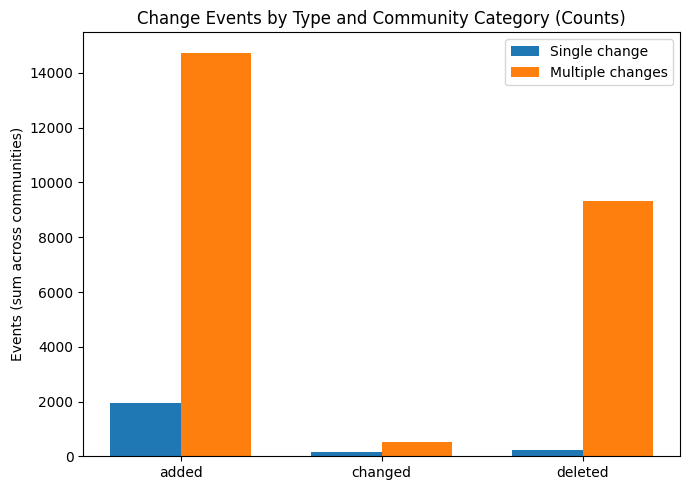

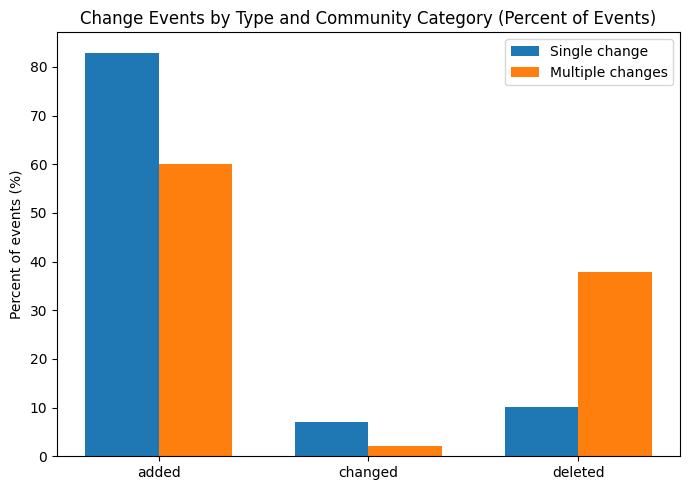

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load data
# -----------------------------
file_path = '/content/drive/My Drive/Projects/Reddit_rules/2024_ChenEtAl_rulechange/sub_level_data.csv'
df = pd.read_csv(file_path)

# -----------------------------
# Ensure numeric dtypes
# -----------------------------
numeric_cols = [
    'added', 'changed', 'deleted', 'unchanged',
    'subscribers_1', 'subscribers_2', 'rules_1', 'rules_2', 'age_in_months'
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

# -----------------------------
# Total changes and categories
# -----------------------------
df['total_changes'] = df[['added', 'changed', 'deleted']].sum(axis=1)

# Drop communities with zero changes across added/changed/deleted
df_changes = df[df['total_changes'] > 0].copy()

# Label single vs multiple (based on number of events, not types)
df_changes['community_category'] = np.where(
    df_changes['total_changes'] == 1, 'single_change', 'multiple_changes'
)

# -----------------------------
# Aggregate EVENT COUNTS (not community counts)
# -----------------------------
agg = (
    df_changes
    .groupby('community_category')[['added', 'changed', 'deleted']]
    .sum()
    .reindex(['single_change', 'multiple_changes'])  # keep stable order
)

# Compute total events per category and percentages
agg['total_events'] = agg[['added', 'changed', 'deleted']].sum(axis=1)
pct = agg[['added', 'changed', 'deleted']].div(agg['total_events'], axis=0) * 100

# Tidy tables for display/printing
counts_long = (
    agg[['added', 'changed', 'deleted']]
      .reset_index()
      .melt(id_vars='community_category', var_name='change_type', value_name='events')
)

pct_long = (
    pct[['added', 'changed', 'deleted']]
      .reset_index()
      .melt(id_vars='community_category', var_name='change_type', value_name='pct_of_events')
)

print("\nEVENT COUNTS by category (sum of events):")
print(agg[['added', 'changed', 'deleted', 'total_events']])

print("\nPERCENT OF EVENTS within category (added/changed/deleted):")
print(pct.round(1))

# -----------------------------
# Plots (counts and percentages)
# -----------------------------
types = ['added', 'changed', 'deleted']
x = np.arange(len(types))
width = 0.35

# Plot 1: Event counts per type (by category)
fig1, ax1 = plt.subplots(figsize=(7, 5))
ax1.bar(x - width/2, agg.loc['single_change', types].values, width, label='Single change')
ax1.bar(x + width/2, agg.loc['multiple_changes', types].values, width, label='Multiple changes')
ax1.set_xticks(x)
ax1.set_xticklabels(types)
ax1.set_ylabel('Events (sum across communities)')
ax1.set_title('Change Events by Type and Community Category (Counts)')
ax1.legend()
plt.tight_layout()
plt.show()

# Plot 2: Percent of events within category
fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.bar(x - width/2, pct.loc['single_change', types].values, width, label='Single change')
ax2.bar(x + width/2, pct.loc['multiple_changes', types].values, width, label='Multiple changes')
ax2.set_xticks(x)
ax2.set_xticklabels(types)
ax2.set_ylabel('Percent of events (%)')
ax2.set_title('Change Events by Type and Community Category (Percent of Events)')
ax2.legend()
plt.tight_layout()
plt.show()


### Community level analysis_Old

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (chi2_contingency, mannwhitneyu, wilcoxon,
                         fisher_exact, ttest_ind, binomtest)
import warnings
warnings.filterwarnings('ignore')

# Load the data
file_path = '/content/drive/My Drive/Projects/Reddit_rules/2024_ChenEtAl_rulechange/sub_level_data.csv'
df = pd.read_csv(file_path)

print("=" * 80)
print("HYPOTHESIS 3 TESTING: CHANGE PATTERNS × CHANGE TYPES INTERACTION")
print("=" * 80)
print("\nH3.0 (Null): Rule additions and deletions occur with equal frequency across")
print("            communities experiencing incremental and bundled changes")
print("\nH3.1: Incremental communities → higher proportion of additions")
print("      Bundled communities → higher proportion of deletions")
print("\nH3.2: Bundled communities → higher proportion of additions")
print("      Incremental communities → higher proportion of deletions")
print("=" * 80)

# ============================================================================
# DATA PREPARATION - COMMUNITY AS UNIT OF ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("DATA PREPARATION: COMMUNITY-LEVEL ANALYSIS")
print("="*70)

# Calculate total changes per community
df['total_changes'] = df['added'] + df['changed'] + df['deleted']
df['has_changes'] = df['total_changes'] > 0

# Filter to communities with changes
df_changed = df[df['has_changes']].copy()

# CRITICAL: Define incremental vs bundled COMMUNITIES
df_changed['is_incremental'] = (df_changed['total_changes'] == 1)
df_changed['is_bundled'] = (df_changed['total_changes'] > 1)

# Calculate proportions at COMMUNITY level
# Each community gets ONE proportion score
df_changed['total_add_del'] = df_changed['added'] + df_changed['deleted']

# Proportion of additions within each community's add/del changes
df_changed['prop_additions'] = np.where(
    df_changed['total_add_del'] > 0,
    df_changed['added'] / df_changed['total_add_del'],
    np.nan
)

df_changed['prop_deletions'] = np.where(
    df_changed['total_add_del'] > 0,
    df_changed['deleted'] / df_changed['total_add_del'],
    np.nan
)

# Separate communities by pattern
incremental_communities = df_changed[df_changed['is_incremental']].copy()
bundled_communities = df_changed[df_changed['is_bundled']].copy()

print("Unit of Analysis: COMMUNITY")
print("\nOperational Definitions:")
print("  - INCREMENTAL COMMUNITY: A community with exactly 1 total change")
print("  - BUNDLED COMMUNITY: A community with 2+ total changes")
print("  - Each community contributes ONE observation to analysis")

print(f"\nSample sizes (COMMUNITIES):")
print(f"  Total communities with changes: {len(df_changed)}")
print(f"  Incremental communities: {len(incremental_communities)} ({len(incremental_communities)/len(df_changed)*100:.1f}%)")
print(f"  Bundled communities: {len(bundled_communities)} ({len(bundled_communities)/len(df_changed)*100:.1f}%)")

# ============================================================================
# DESCRIPTIVE STATISTICS - COMMUNITY LEVEL
# ============================================================================
print("\n" + "="*70)
print("DESCRIPTIVE STATISTICS BY COMMUNITY TYPE")
print("="*70)

print("\n1. INCREMENTAL COMMUNITIES (n={})".format(len(incremental_communities)))
print("-" * 40)

# For incremental communities, categorize the single change
inc_single_addition = (incremental_communities['added'] == 1).sum()
inc_single_change = (incremental_communities['changed'] == 1).sum()
inc_single_deletion = (incremental_communities['deleted'] == 1).sum()

print(f"  Communities with single addition: {inc_single_addition} ({inc_single_addition/len(incremental_communities)*100:.1f}%)")
print(f"  Communities with single modification: {inc_single_change} ({inc_single_change/len(incremental_communities)*100:.1f}%)")
print(f"  Communities with single deletion: {inc_single_deletion} ({inc_single_deletion/len(incremental_communities)*100:.1f}%)")

# Among those with add OR del only
inc_add_or_del = incremental_communities[(incremental_communities['added'] > 0) |
                                         (incremental_communities['deleted'] > 0)]
inc_add_or_del_only = inc_add_or_del[inc_add_or_del['changed'] == 0]

if len(inc_add_or_del_only) > 0:
    inc_add_proportion = (inc_add_or_del_only['added'] > 0).mean()
    print(f"\n  Among incremental communities with add/del (excluding modifications):")
    print(f"    Proportion with additions: {inc_add_proportion:.3f}")
    print(f"    Proportion with deletions: {1-inc_add_proportion:.3f}")

print("\n2. BUNDLED COMMUNITIES (n={})".format(len(bundled_communities)))
print("-" * 40)

# For bundled communities, look at means and proportions
print(f"  Mean additions per community: {bundled_communities['added'].mean():.2f} (SD={bundled_communities['added'].std():.2f})")
print(f"  Mean deletions per community: {bundled_communities['deleted'].mean():.2f} (SD={bundled_communities['deleted'].std():.2f})")
print(f"  Mean modifications per community: {bundled_communities['changed'].mean():.2f} (SD={bundled_communities['changed'].std():.2f})")

# Proportion analysis for bundled communities
bundled_with_add_del = bundled_communities[bundled_communities['total_add_del'] > 0]
if len(bundled_with_add_del) > 0:
    print(f"\n  Among bundled communities with any add/del (n={len(bundled_with_add_del)}):")
    print(f"    Mean proportion of additions: {bundled_with_add_del['prop_additions'].mean():.3f}")
    print(f"    Median proportion of additions: {bundled_with_add_del['prop_additions'].median():.3f}")
    print(f"    Communities where additions > deletions: {(bundled_with_add_del['prop_additions'] > 0.5).sum()} ({(bundled_with_add_del['prop_additions'] > 0.5).mean()*100:.1f}%)")
    print(f"    Communities where deletions > additions: {(bundled_with_add_del['prop_additions'] < 0.5).sum()} ({(bundled_with_add_del['prop_additions'] < 0.5).mean()*100:.1f}%)")

# ============================================================================
# TEST 1: COMPARING PROPORTION OF ADDITIONS - PRIMARY TEST
# ============================================================================
print("\n" + "="*70)
print("TEST 1: MANN-WHITNEY U TEST - COMPARING COMMUNITIES")
print("="*70)
print("H0: Communities have same proportion of additions regardless of pattern")

# Get proportions for each community type
# For incremental: prop is either 0 (deletion) or 1 (addition) or NaN (modification)
inc_props = incremental_communities['prop_additions'].dropna()
bun_props = bundled_communities['prop_additions'].dropna()

if len(inc_props) > 0 and len(bun_props) > 0:
    # Mann-Whitney U test
    u_stat, p_mw = mannwhitneyu(inc_props, bun_props, alternative='two-sided')

    print(f"\nSample sizes:")
    print(f"  Incremental communities (with add/del): {len(inc_props)}")
    print(f"  Bundled communities (with add/del): {len(bun_props)}")

    print(f"\nDescriptive statistics:")
    print(f"  Incremental - Mean prop additions: {inc_props.mean():.3f}")
    print(f"  Incremental - Median prop additions: {inc_props.median():.3f}")
    print(f"  Bundled - Mean prop additions: {bun_props.mean():.3f}")
    print(f"  Bundled - Median prop additions: {bun_props.median():.3f}")

    print(f"\nTest results:")
    print(f"  Mann-Whitney U statistic: {u_stat:.1f}")
    print(f"  P-value (two-tailed): {p_mw:.4f}")

    # Effect size (rank-biserial correlation)
    n1, n2 = len(inc_props), len(bun_props)
    r_rb = 1 - (2*u_stat) / (n1 * n2)
    print(f"  Rank-biserial correlation: {r_rb:.3f}")

    if p_mw < 0.05:
        if inc_props.median() > bun_props.median():
            print("\n**RESULT: SUPPORTS H3.1 - Incremental communities have higher proportion of additions**")
        else:
            print("\n**RESULT: SUPPORTS H3.2 - Bundled communities have higher proportion of additions**")
    else:
        print("\n**RESULT: SUPPORTS H3.0 - No significant difference**")

# ============================================================================
# TEST 2: T-TEST FOR INDEPENDENT SAMPLES
# ============================================================================
print("\n" + "="*70)
print("TEST 2: INDEPENDENT SAMPLES T-TEST")
print("="*70)

if len(inc_props) > 0 and len(bun_props) > 0:
    # Welch's t-test (doesn't assume equal variances)
    t_stat, p_t = ttest_ind(inc_props, bun_props, equal_var=False)

    print(f"Welch's t-test (comparing mean proportions):")
    print(f"  T-statistic: {t_stat:.3f}")
    print(f"  P-value (two-tailed): {p_t:.4f}")

    # Cohen's d effect size
    pooled_std = np.sqrt((inc_props.var() + bun_props.var()) / 2)
    cohens_d = (inc_props.mean() - bun_props.mean()) / pooled_std
    print(f"  Cohen's d: {cohens_d:.3f}")

    effect_interpretation = "small" if abs(cohens_d) < 0.5 else "medium" if abs(cohens_d) < 0.8 else "large"
    print(f"  Effect size interpretation: {effect_interpretation}")

# ============================================================================
# TEST 3: CHI-SQUARE TEST - CATEGORICAL APPROACH
# ============================================================================
print("\n" + "="*70)
print("TEST 3: CHI-SQUARE TEST OF INDEPENDENCE")
print("="*70)

# Create categories for each community
def categorize_community(row):
    if row['total_add_del'] == 0:
        return 'no_add_del'
    elif row['prop_additions'] > 0.5:
        return 'addition_dominant'
    elif row['prop_deletions'] < 0.5:
        return 'deletion_dominant'
    else:
        return 'balanced'

df_changed['dominance_category'] = df_changed.apply(categorize_community, axis=1)

# Create contingency table
contingency = pd.crosstab(
    df_changed['is_incremental'].map({True: 'Incremental', False: 'Bundled'}),
    df_changed['dominance_category'],
    margins=False
)

print("\nContingency Table (Communities by Pattern and Dominance):")
print(contingency)

# Filter to just addition vs deletion dominant for cleaner test
contingency_clean = pd.crosstab(
    df_changed[df_changed['dominance_category'].isin(['addition_dominant', 'deletion_dominant'])]['is_incremental'],
    df_changed[df_changed['dominance_category'].isin(['addition_dominant', 'deletion_dominant'])]['dominance_category']
)

if contingency_clean.shape == (2, 2):
    chi2, p_chi2, dof, expected = chi2_contingency(contingency_clean)

    print(f"\nChi-square test (addition vs deletion dominant only):")
    print(f"  Chi-square statistic: {chi2:.3f}")
    print(f"  P-value: {p_chi2:.4f}")
    print(f"  Degrees of freedom: {dof}")

    # Cramér's V
    n = contingency_clean.sum().sum()
    cramers_v = np.sqrt(chi2 / n)
    print(f"  Cramér's V: {cramers_v:.3f}")

    # Odds ratio from contingency table
    if contingency_clean.shape == (2, 2):
        a = contingency_clean.iloc[0, 0]  # incremental-addition
        b = contingency_clean.iloc[0, 1]  # incremental-deletion
        c = contingency_clean.iloc[1, 0]  # bundled-addition
        d = contingency_clean.iloc[1, 1]  # bundled-deletion

        if b > 0 and c > 0:
            odds_ratio = (a * d) / (b * c)
            print(f"  Odds ratio: {odds_ratio:.3f}")

            if odds_ratio > 1:
                print(f"  Interpretation: Incremental communities are {odds_ratio:.2f}x more likely to be addition-dominant")
            else:
                print(f"  Interpretation: Bundled communities are {1/odds_ratio:.2f}x more likely to be addition-dominant")

# ============================================================================
# TEST 4: BOOTSTRAP CONFIDENCE INTERVALS
# ============================================================================
print("\n" + "="*70)
print("TEST 4: BOOTSTRAP ANALYSIS (10,000 iterations)")
print("="*70)

n_bootstrap = 10000
np.random.seed(42)

# Bootstrap the difference in mean proportions
diff_means_boot = []
inc_means_boot = []
bun_means_boot = []

for _ in range(n_bootstrap):
    # Sample with replacement from each group
    if len(inc_props) > 0:
        inc_sample = np.random.choice(inc_props, size=len(inc_props), replace=True)
        inc_mean = inc_sample.mean()
    else:
        inc_mean = np.nan

    if len(bun_props) > 0:
        bun_sample = np.random.choice(bun_props, size=len(bun_props), replace=True)
        bun_mean = bun_sample.mean()
    else:
        bun_mean = np.nan

    if not np.isnan(inc_mean) and not np.isnan(bun_mean):
        inc_means_boot.append(inc_mean)
        bun_means_boot.append(bun_mean)
        diff_means_boot.append(inc_mean - bun_mean)

diff_means_boot = np.array(diff_means_boot)
ci_lower = np.percentile(diff_means_boot, 2.5)
ci_upper = np.percentile(diff_means_boot, 97.5)

print(f"Bootstrap results:")
print(f"  Mean proportion additions - Incremental: {np.mean(inc_means_boot):.3f}")
print(f"  Mean proportion additions - Bundled: {np.mean(bun_means_boot):.3f}")
print(f"  Mean difference (Incremental - Bundled): {diff_means_boot.mean():.3f}")
print(f"  95% CI for difference: [{ci_lower:.3f}, {ci_upper:.3f}]")

if ci_lower > 0:
    print("\n**RESULT: SUPPORTS H3.1 - Incremental communities have significantly higher proportion of additions**")
elif ci_upper < 0:
    print("\n**RESULT: SUPPORTS H3.2 - Bundled communities have significantly higher proportion of additions**")
else:
    print("\n**RESULT: SUPPORTS H3.0 - No significant difference (CI includes 0)**")

# ============================================================================
# TEST 5: LOGISTIC REGRESSION WITH CONTROLS
# ============================================================================
print("\n" + "="*70)
print("TEST 5: LOGISTIC REGRESSION (Controlling for Size and Age)")
print("="*70)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Prepare data - each community is one observation
df_reg = df_changed[df_changed['total_add_del'] > 0].copy()
df_reg['addition_dominant'] = (df_reg['prop_additions'] > 0.5).astype(int)
df_reg['is_bundled'] = df_reg['is_bundled'].astype(int)
df_reg['log_subscribers'] = np.log10(df_reg['subscribers_2'] + 1)
df_reg['log_age'] = np.log10(df_reg['age_in_months'] + 1)

# Remove missing values
df_reg_clean = df_reg[['addition_dominant', 'is_bundled', 'log_subscribers', 'log_age']].dropna()

if len(df_reg_clean) > 30:  # Need sufficient sample size
    X = df_reg_clean[['is_bundled', 'log_subscribers', 'log_age']]
    y = df_reg_clean['addition_dominant']

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Fit logistic regression
    log_reg = LogisticRegression(random_state=42, max_iter=1000)
    log_reg.fit(X_scaled, y)

    print(f"Sample size: {len(df_reg_clean)} communities")
    print("\nLogistic Regression Coefficients:")
    print(f"  Is Bundled (vs Incremental): {log_reg.coef_[0][0]:.3f}")
    print(f"  Log(Subscribers): {log_reg.coef_[0][1]:.3f}")
    print(f"  Log(Age): {log_reg.coef_[0][2]:.3f}")
    print(f"  Intercept: {log_reg.intercept_[0]:.3f}")

    # Calculate odds ratios
    odds_ratios = np.exp(log_reg.coef_[0])
    print("\nOdds Ratios:")
    print(f"  Bundled vs Incremental: {odds_ratios[0]:.3f}")

    if odds_ratios[0] > 1:
        print(f"  Interpretation: Bundled communities are {odds_ratios[0]:.2f}x more likely to be addition-dominant")
        print("  **Supports H3.2**")
    else:
        print(f"  Interpretation: Incremental communities are {1/odds_ratios[0]:.2f}x more likely to be addition-dominant")
        print("  **Supports H3.1**")

# ============================================================================
# TEST 6: PERMUTATION TEST
# ============================================================================
print("\n" + "="*70)
print("TEST 6: PERMUTATION TEST (10,000 permutations)")
print("="*70)

# Observed difference
obs_diff = inc_props.mean() - bun_props.mean() if len(inc_props) > 0 and len(bun_props) > 0 else 0

# Combine all proportions and labels
all_props = np.concatenate([inc_props, bun_props])
all_labels = np.concatenate([np.ones(len(inc_props)), np.zeros(len(bun_props))])

# Permutation test
n_permutations = 10000
perm_diffs = []

np.random.seed(42)
for _ in range(n_permutations):
    # Shuffle labels
    shuffled_labels = np.random.permutation(all_labels)

    # Calculate difference for shuffled data
    group1_mean = all_props[shuffled_labels == 1].mean()
    group2_mean = all_props[shuffled_labels == 0].mean()
    perm_diffs.append(group1_mean - group2_mean)

perm_diffs = np.array(perm_diffs)
p_perm = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))

print(f"Permutation test results:")
print(f"  Observed difference: {obs_diff:.3f}")
print(f"  P-value (two-tailed): {p_perm:.4f}")

if p_perm < 0.05:
    if obs_diff > 0:
        print("  **RESULT: Supports H3.1 - Incremental communities have more additions**")
    else:
        print("  **RESULT: Supports H3.2 - Bundled communities have more additions**")
else:
    print("  **RESULT: Supports H3.0 - No significant difference**")

# ============================================================================
# TEST 7: SENSITIVITY ANALYSIS - DIFFERENT BUNDLED SIZES
# ============================================================================
print("\n" + "="*70)
print("TEST 7: SENSITIVITY ANALYSIS - BUNDLED COMMUNITY SIZES")
print("="*70)

# Analyze bundled communities by size
bundled_communities['bundle_size'] = pd.cut(
    bundled_communities['total_changes'],
    bins=[1, 2, 3, 5, float('inf')],
    labels=['2 changes', '3 changes', '4-5 changes', '6+ changes']
)

print("\nProportion of additions by bundle size:")
for size in ['2 changes', '3 changes', '4-5 changes', '6+ changes']:
    subset = bundled_communities[bundled_communities['bundle_size'] == size]
    subset_with_add_del = subset[subset['total_add_del'] > 0]

    if len(subset_with_add_del) > 0:
        mean_prop = subset_with_add_del['prop_additions'].mean()
        median_prop = subset_with_add_del['prop_additions'].median()
        n = len(subset_with_add_del)
        print(f"  {size} (n={n}): Mean={mean_prop:.3f}, Median={median_prop:.3f}")

# ============================================================================
# FINAL HYPOTHESIS EVALUATION
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE HYPOTHESIS EVALUATION")
print("="*80)

# Compile test results
test_results = []

if 'p_mw' in locals():
    test_results.append(('Mann-Whitney U', p_mw,
                        'H3.1' if inc_props.median() > bun_props.median() and p_mw < 0.05 else
                        'H3.2' if inc_props.median() < bun_props.median() and p_mw < 0.05 else 'H3.0'))

if 'p_t' in locals():
    test_results.append(('T-test', p_t,
                        'H3.1' if t_stat > 0 and p_t < 0.05 else
                        'H3.2' if t_stat < 0 and p_t < 0.05 else 'H3.0'))

if 'p_chi2' in locals():
    test_results.append(('Chi-square', p_chi2,
                        'H3.1' if odds_ratio > 1 and p_chi2 < 0.05 else
                        'H3.2' if odds_ratio < 1 and p_chi2 < 0.05 else 'H3.0'))

test_results.append(('Bootstrap CI', 1.0 if ci_lower <= 0 <= ci_upper else 0.001,
                    'H3.1' if ci_lower > 0 else
                    'H3.2' if ci_upper < 0 else 'H3.0'))

if 'p_perm' in locals():
    test_results.append(('Permutation', p_perm,
                        'H3.1' if obs_diff > 0 and p_perm < 0.05 else
                        'H3.2' if obs_diff < 0 and p_perm < 0.05 else 'H3.0'))

print("\nTEST SUMMARY:")
print("-" * 70)
print(f"{'Test':<20} {'P-value':<12} {'Supports':<10}")
print("-" * 70)

h30_count = 0
h31_count = 0
h32_count = 0

for test_name, p_val, hypothesis in test_results:
    print(f"{test_name:<20} {p_val:<12.4f} {hypothesis:<10}")
    if hypothesis == 'H3.0':
        h30_count += 1
    elif hypothesis == 'H3.1':
        h31_count += 1
    elif hypothesis == 'H3.2':
        h32_count += 1

print("-" * 70)
print(f"\nHypothesis Support Count:")
print(f"  H3.0 (No difference): {h30_count} tests")
print(f"  H3.1 (Inc→Add, Bun→Del): {h31_count} tests")
print(f"  H3.2 (Bun→Add, Inc→Del): {h32_count} tests")

# Final verdict
print("\n" + "="*60)
if h31_count > h30_count and h31_count > h32_count:
    print("FINAL VERDICT: SUPPORT FOR H3.1")
    print("\nIncremental communities show higher proportions of additions,")
    print("while bundled communities show higher proportions of deletions.")
elif h32_count > h30_count and h32_count > h31_count:
    print("FINAL VERDICT: SUPPORT FOR H3.2")
    print("\nBundled communities show higher proportions of additions,")
    print("while incremental communities show higher proportions of deletions.")
else:
    print("FINAL VERDICT: SUPPORT FOR H3.0 (NULL HYPOTHESIS)")
    print("\nRule additions and deletions occur with equal frequency across")
    print("communities experiencing incremental and bundled changes.")
print("="*60)

# Key statistics for reporting
print("\n" + "="*60)
print("KEY STATISTICS FOR REPORTING:")
print("="*60)
print(f"\nIncremental Communities (n={len(incremental_communities)}):")
if len(inc_props) > 0:
    print(f"  • Mean proportion of additions: {inc_props.mean():.3f}")
    print(f"  • Median proportion of additions: {inc_props.median():.3f}")
    print(f"  • {(inc_props > 0.5).sum()} communities ({(inc_props > 0.5).mean()*100:.1f}%) are addition-dominant")

print(f"\nBundled Communities (n={len(bundled_communities)}):")
if len(bun_props) > 0:
    print(f"  • Mean proportion of additions: {bun_props.mean():.3f}")
    print(f"  • Median proportion of additions: {bun_props.median():.3f}")
    print(f"  • {(bun_props > 0.5).sum()} communities ({(bun_props > 0.5).mean()*100:.1f}%) are addition-dominant")

if 'u_stat' in locals():
    print(f"\nEffect Sizes:")
    print(f"  • Rank-biserial correlation: {r_rb:.3f}")
    print(f"  • Cohen's d: {cohens_d:.3f}")
    if 'cramers_v' in locals():
        print(f"  • Cramér's V: {cramers_v:.3f}")

print("="*60)
print("\nAnalysis complete!")

HYPOTHESIS 3 TESTING: CHANGE PATTERNS × CHANGE TYPES INTERACTION

H3.0 (Null): Rule additions and deletions occur with equal frequency across
            communities experiencing incremental and bundled changes

H3.1: Incremental communities → higher proportion of additions
      Bundled communities → higher proportion of deletions

H3.2: Bundled communities → higher proportion of additions
      Incremental communities → higher proportion of deletions

DATA PREPARATION: COMMUNITY-LEVEL ANALYSIS
Unit of Analysis: COMMUNITY

Operational Definitions:
  - INCREMENTAL COMMUNITY: A community with exactly 1 total change
  - BUNDLED COMMUNITY: A community with 2+ total changes
  - Each community contributes ONE observation to analysis

Sample sizes (COMMUNITIES):
  Total communities with changes: 6948
  Incremental communities: 2360 (34.0%)
  Bundled communities: 4588 (66.0%)

DESCRIPTIVE STATISTICS BY COMMUNITY TYPE

1. INCREMENTAL COMMUNITIES (n=2360)
---------------------------------------

## Hypotheses demos

H1: Most communities primarily evolve through rule additions. (Test: chi-squared)


H2: Communities are more likely to undergo incremental (single-rule) changes rather than bundled (multiple-rule) changes.

H3_0: (Null Hypothesis): Rule additions and deletions occur with equal frequency across communities experiencing incremental and bundled changes.

H3.1: Communities undergoing incremental (single) changes show higher proportions of rule additions than deletions, while communities undergoing bundled changes show higher proportions of rule deletions than additions.

H3.2: Communities undergoing bundled changes show higher proportions of rule additions than deletions, while communities undergoing incremental changes show higher proportions of rule deletions than additions.


# Descriptive Statistics

In [ ]:
# Load the CSV file
file_path = '/content/drive/My Drive/Projects/Reddit_rules/2024_ChenEtAl_rulechange/sub_level_data.csv'
df = pd.read_csv(file_path)

# Columns to analyze
cols_to_analyze = ['added', 'changed', 'deleted', 'unchanged', 'subscribers_1', 'subscribers_2', 'rules_1', 'rules_2']

# Statistical calculations
stats = {
    'range': df[cols_to_analyze].max() - df[cols_to_analyze].min(),
    'mean': df[cols_to_analyze].mean(),
    'median': df[cols_to_analyze].median(),
    'std_dev': df[cols_to_analyze].std()
}

# Convert age_in_months to years and calculate stats
df['age_in_years'] = df['age_in_months'] / 12
stats['age_in_years'] = {
    'range': df['age_in_years'].max() - df['age_in_years'].min(),
    'mean': df['age_in_years'].mean(),
    'median': df['age_in_years'].median(),
    'std_dev': df['age_in_years'].std()
}

# Display results
for key, value in stats.items():
    print(f"\n{key.capitalize()}:")
    print(value)


Range:
added                  15.0
changed                 5.0
deleted                15.0
unchanged              15.0
subscribers_1    36440855.0
subscribers_2    38255392.0
rules_1                14.0
rules_2                15.0
dtype: float64

Mean:
added                0.127664
changed              0.005166
deleted              0.073045
unchanged            3.806459
subscribers_1    23501.689616
subscribers_2    26231.873367
rules_1              3.890830
rules_2              3.939290
dtype: float64

Median:
added             0.0
changed           0.0
deleted           0.0
unchanged         3.0
subscribers_1    82.0
subscribers_2    95.0
rules_1           3.0
rules_2           3.0
dtype: float64

Std_dev:
added                 0.766964
changed               0.087530
deleted               0.566912
unchanged             2.521422
subscribers_1    423660.566647
subscribers_2    441586.221077
rules_1               2.565885
rules_2               2.608311
dtype: float64

Age_in_years:
{'r

# Statistic Tests

In [ ]:
import pandas as pd
import numpy as np

# ----- Load and Preprocess Data -----
# Read the CSV file containing subreddit rule-change data.
file_path = '/content/drive/My Drive/Projects/Reddit_rules/2024_ChenEtAl_rulechange/sub_level_data.csv'
df = pd.read_csv(file_path)

# Compute the total number of rule changes (only count added, changed, deleted).
df['total_change'] = df['added'] + df['changed'] + df['deleted']

# Keep only communities where a rule change occurred.
df_changes = df[df['total_change'] > 0].copy()

# Define change type: incremental if exactly one rule changed; bundled if more than one.
df_changes['change_type'] = np.where(df_changes['total_change'] == 1, 'incremental', 'bundled')

# Optional: inspect counts of each group.
print("Number of incremental communities:", (df_changes['change_type'] == 'incremental').sum())
print("Number of bundled communities:", (df_changes['change_type'] == 'bundled').sum())

# Separate the data into two groups.
incremental_data = df_changes[df_changes['change_type'] == 'incremental']
bundled_data = df_changes[df_changes['change_type'] == 'bundled']

# ----- Bootstrapping Function -----
def bootstrap_proportions(data, n_iterations=1000, seed=42):
    """
    Bootstrap the proportions of rule additions and deletions.

    For each bootstrap iteration, we sample the rows (with replacement) and compute:
      - proportion of additions: (sum of 'added') / (total changes)
      - proportion of deletions: (sum of 'deleted') / (total changes)
    """
    np.random.seed(seed)
    boot_add = []
    boot_del = []

    for i in range(n_iterations):
        sample = data.sample(frac=1, replace=True)
        total_changes = sample['total_change'].sum()
        # Guard against division by zero (should not happen if filtering was done correctly)
        prop_add = sample['added'].sum() / total_changes if total_changes > 0 else np.nan
        prop_del = sample['deleted'].sum() / total_changes if total_changes > 0 else np.nan

        boot_add.append(prop_add)
        boot_del.append(prop_del)

    return np.array(boot_add), np.array(boot_del)

# Run bootstrap for each group.
boot_add_inc, boot_del_inc = bootstrap_proportions(incremental_data)
boot_add_bund, boot_del_bund = bootstrap_proportions(bundled_data)

# ----- Compute 95% Highest Credible Intervals (HCIs) -----
def calc_hci(bootstrap_array, lower=2.5, upper=97.5):
    """Compute the HCIs using the given lower and upper percentiles."""
    return np.percentile(bootstrap_array, [lower, upper])

# HCIs for incremental changes.
hci_add_inc = calc_hci(boot_add_inc)
hci_del_inc = calc_hci(boot_del_inc)

# HCIs for bundled changes.
hci_add_bund = calc_hci(boot_add_bund)
hci_del_bund = calc_hci(boot_del_bund)

# Print the results for each group.
print("\nIncremental Changes:")
print(f"Mean addition proportion: {np.mean(boot_add_inc):.3f}, 95% HCI: {hci_add_inc}")
print(f"Mean deletion proportion: {np.mean(boot_del_inc):.3f}, 95% HCI: {hci_del_inc}")

print("\nBundled Changes:")
print(f"Mean addition proportion: {np.mean(boot_add_bund):.3f}, 95% HCI: {hci_add_bund}")
print(f"Mean deletion proportion: {np.mean(boot_del_bund):.3f}, 95% HCI: {hci_del_bund}")

# ----- Testing Differences Between Incremental and Bundled Groups -----
# We expect incremental changes to be dominated by additions and bundled changes to have more deletions.
# Compute the bootstrap difference between groups:
# For additions: (incremental - bundled) should be positive if incremental changes have a higher addition rate.
boot_diff_add = boot_add_inc - boot_add_bund
# For deletions: (bundled - incremental) should be positive if bundled changes have a higher deletion rate.
boot_diff_del = boot_del_bund - boot_del_inc

hci_diff_add = calc_hci(boot_diff_add)
hci_diff_del = calc_hci(boot_diff_del)

print("\nDifferences Between Groups:")
print(f"Difference in addition proportion (incremental - bundled): Mean = {np.mean(boot_diff_add):.3f}, 95% HCI: {hci_diff_add}")
print(f"Difference in deletion proportion (bundled - incremental): Mean = {np.mean(boot_diff_del):.3f}, 95% HCI: {hci_diff_del}")

# Interpretation:
# If the 95% HCI for the difference in addition proportions is entirely above 0, it supports that
# incremental changes are significantly more likely to be additions.
# Similarly, if the 95% HCI for the difference in deletion proportions is entirely above 0,
# it supports that bundled changes are significantly more likely to be deletions.


Number of incremental communities: 2360
Number of bundled communities: 4588

Incremental Changes:
Mean addition proportion: 0.830, 95% HCI: [0.81439619 0.84491525]
Mean deletion proportion: 0.101, 95% HCI: [0.08771186 0.11313559]

Bundled Changes:
Mean addition proportion: 0.600, 95% HCI: [0.59362096 0.60632302]
Mean deletion proportion: 0.379, 95% HCI: [0.37286149 0.38542432]

Differences Between Groups:
Difference in addition proportion (incremental - bundled): Mean = 0.230, 95% HCI: [0.21300115 0.24573802]
Difference in deletion proportion (bundled - incremental): Mean = 0.278, 95% HCI: [0.26448007 0.29261031]


Logit Regression

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# ----- Data Preparation -----
# Load the data.
file_path = '/content/drive/My Drive/Projects/Reddit_rules/2024_ChenEtAl_rulechange/sub_level_data.csv'
df = pd.read_csv(file_path)

# Compute the total number of rule changes (only counting added, changed, deleted).
df['total_change'] = df['added'] + df['changed'] + df['deleted']

# Keep only subreddits with at least one rule change.
df_changes = df[df['total_change'] > 0].copy()

# Define the type of rule change:
# Incremental if exactly one rule changed; bundled if more than one.
df_changes['change_type'] = np.where(df_changes['total_change'] == 1, 'incremental', 'bundled')

# Create a binary outcome:
# 0 = incremental, 1 = bundled.
df_changes['bundled_binary'] = (df_changes['change_type'] == 'bundled').astype(int)

# Compute the log of the subscriber count (adding 1 to avoid log(0)).
df_changes['log_subscribers'] = np.log(df_changes['subscribers_1'] + 1)

# ----- Original Logistic Regression Model (for reference) -----
model = smf.logit('bundled_binary ~ rules_1 + age_in_months + log_subscribers', data=df_changes)
result = model.fit()
print(result.summary())

# ----- Logistic Regression with Interaction Terms -----
# Here we include two interaction terms:
# 1. rules_1 * age_in_months: to assess if the effect of initial rule count changes with subreddit age.
# 2. log_subscribers * age_in_months: to see if the effect of community size differs by subreddit age.
model_interaction = smf.logit('bundled_binary ~ rules_1 * age_in_months + log_subscribers * age_in_months', data=df_changes)
result_interaction = model_interaction.fit()
print(result_interaction.summary())

Optimization terminated successfully.
         Current function value: 0.632294
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:         bundled_binary   No. Observations:                 6948
Model:                          Logit   Df Residuals:                     6944
Method:                           MLE   Df Model:                            3
Date:                Thu, 16 Oct 2025   Pseudo R-squ.:                 0.01330
Time:                        19:55:29   Log-Likelihood:                -4393.2
converged:                       True   LL-Null:                       -4452.4
Covariance Type:            nonrobust   LLR p-value:                 1.715e-25
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.5618      0.088      6.406      0.000       0.390       0.734
rules_1       

# Statistic Validation (old)

## Statistic Inference

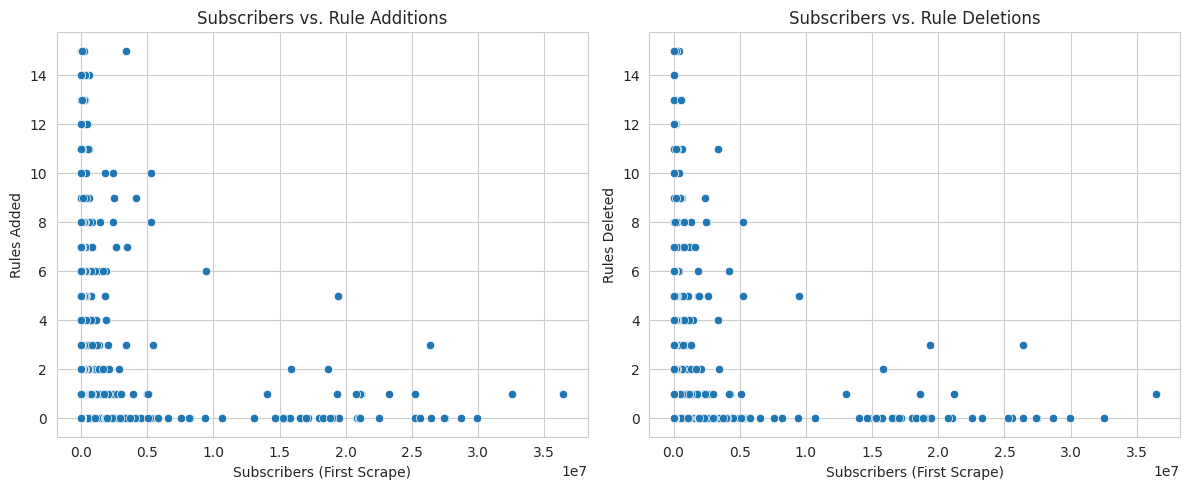

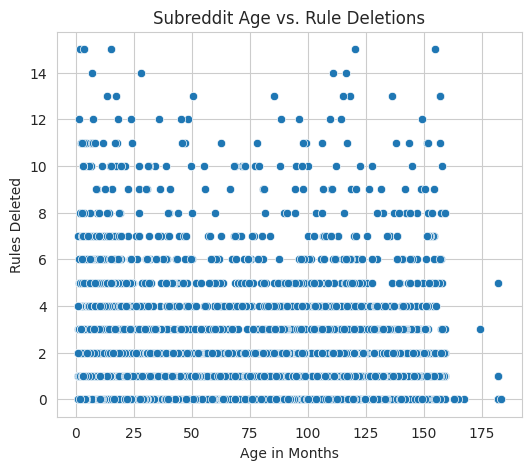

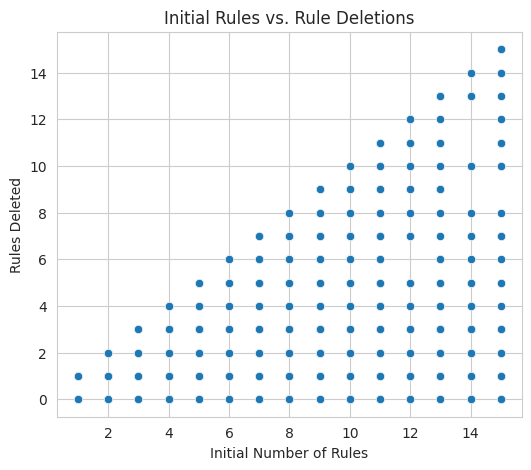

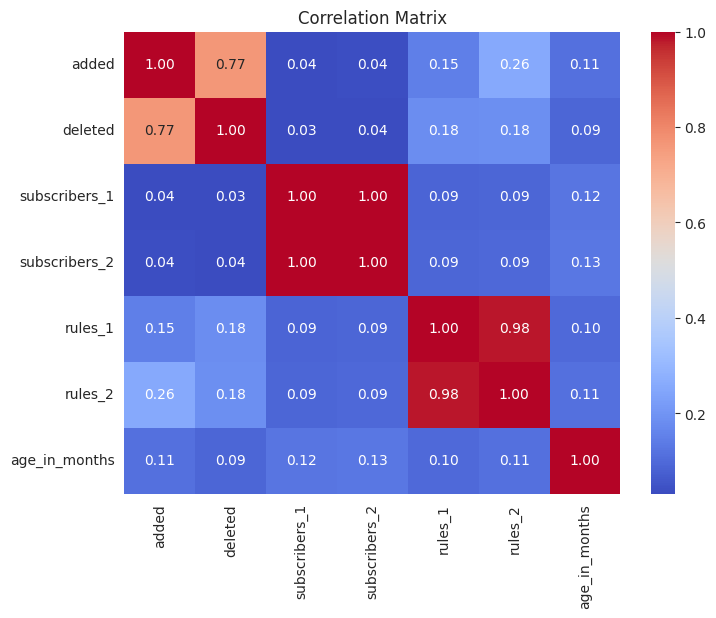

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# 1. Subreddit Size and Rule Changes
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(x=df["subscribers_1"], y=df["added"], ax=axes[0])
axes[0].set_title("Subscribers vs. Rule Additions")
axes[0].set_xlabel("Subscribers (First Scrape)")
axes[0].set_ylabel("Rules Added")

sns.scatterplot(x=df["subscribers_1"], y=df["deleted"], ax=axes[1])
axes[1].set_title("Subscribers vs. Rule Deletions")
axes[1].set_xlabel("Subscribers (First Scrape)")
axes[1].set_ylabel("Rules Deleted")

plt.tight_layout()
plt.show()

# 2. Subreddit Age and Rule Deletions
plt.figure(figsize=(6, 5))
sns.scatterplot(x=df["age_in_months"], y=df["deleted"])
plt.title("Subreddit Age vs. Rule Deletions")
plt.xlabel("Age in Months")
plt.ylabel("Rules Deleted")
plt.show()

# 3. Initial Rule Count and Rule Deletions
plt.figure(figsize=(6, 5))
sns.scatterplot(x=df["rules_1"], y=df["deleted"])
plt.title("Initial Rules vs. Rule Deletions")
plt.xlabel("Initial Number of Rules")
plt.ylabel("Rules Deleted")
plt.show()

# Correlation Analysis
correlation_matrix = df[["added", "deleted", "subscribers_1", "subscribers_2", "rules_1", "rules_2", "age_in_months"]].corr()

# Display heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Pearson Correlation Tests
print("\n=== Pearson Correlation Tests ===")
variables = ["subscribers_1", "subscribers_2", "rules_1", "rules_2", "age_in_months"]

for var in variables:
    corr_added, p_added = stats.pearsonr(df[var], df["added"])
    corr_deleted, p_deleted = stats.pearsonr(df[var], df["deleted"])
    print(f"{var} vs. added: Pearson r={corr_added:.2f}, p-value={p_added:.4f}")
    print(f"{var} vs. deleted: Pearson r={corr_deleted:.2f}, p-value={p_deleted:.4f}")

# 2. Multiple Linear Regression with Control Variables
print("\n=== Multiple Linear Regression Analysis with Controls ===")

# Rule Additions ~ Subscribers + Controls
model1 = smf.ols("added ~ subscribers_1 + age_in_months + rules_1", data=df).fit()
print("\nRegression: Rules Added ~ Subscribers + Age + Initial Rules")
print(model1.summary())

# Rule Deletions ~ Age + Controls
model2 = smf.ols("deleted ~ age_in_months + subscribers_1 + rules_1", data=df).fit()
print("\nRegression: Rules Deleted ~ Age + Subscribers + Initial Rules")
print(model2.summary())

# Rule Deletions ~ Initial Rules + Controls
model3 = smf.ols("deleted ~ rules_1 + age_in_months + subscribers_1", data=df).fit()
print("\nRegression: Rules Deleted ~ Initial Rules + Age + Subscribers")
print(model3.summary())

# 3. T-Tests (Comparing High vs. Low Subreddit Sizes)
median_subs = df["subscribers_1"].median()
df["large_subreddit"] = df["subscribers_1"] > median_subs

t_stat, p_val = stats.ttest_ind(df[df["large_subreddit"]]["deleted"], df[~df["large_subreddit"]]["deleted"])
print("\nT-Test: Do Larger Subreddits Delete More Rules?")
print(f"T-statistic={t_stat:.2f}, p-value={p_val:.4f}")

# 4. ANOVA (Checking Multiple Group Differences in Rule Deletions)
df["age_group"] = pd.qcut(df["age_in_months"], 3, labels=["Young", "Middle", "Old"])

anova_result = smf.ols("deleted ~ C(age_group) + subscribers_1 + rules_1", data=df).fit()
anova_table = sm.stats.anova_lm(anova_result, typ=2)

print("\nANOVA: Do Older Subreddits Delete More Rules (Controlling for Size & Initial Rules)?")
print(anova_table)


=== Pearson Correlation Tests ===
subscribers_1 vs. added: Pearson r=0.04, p-value=0.0000
subscribers_1 vs. deleted: Pearson r=0.03, p-value=0.0000
subscribers_2 vs. added: Pearson r=0.04, p-value=0.0000
subscribers_2 vs. deleted: Pearson r=0.04, p-value=0.0000
rules_1 vs. added: Pearson r=0.15, p-value=0.0000
rules_1 vs. deleted: Pearson r=0.18, p-value=0.0000
rules_2 vs. added: Pearson r=0.26, p-value=0.0000
rules_2 vs. deleted: Pearson r=0.18, p-value=0.0000
age_in_months vs. added: Pearson r=0.11, p-value=0.0000
age_in_months vs. deleted: Pearson r=0.09, p-value=0.0000

=== Multiple Linear Regression Analysis with Controls ===

Regression: Rules Added ~ Subscribers + Age + Initial Rules
                            OLS Regression Results                            
Dep. Variable:                  added   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:          

<ipython-input-12-59c2294501cb>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["age_group"], y=df["deleted"], palette=palette, width=0.6, showfliers=False)
<ipython-input-12-59c2294501cb>:12: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.boxplot(x=df["age_group"], y=df["deleted"], palette=palette, width=0.6, showfliers=False)
<ipython-input-12-59c2294501cb>:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby("age_group")["deleted"].mean()


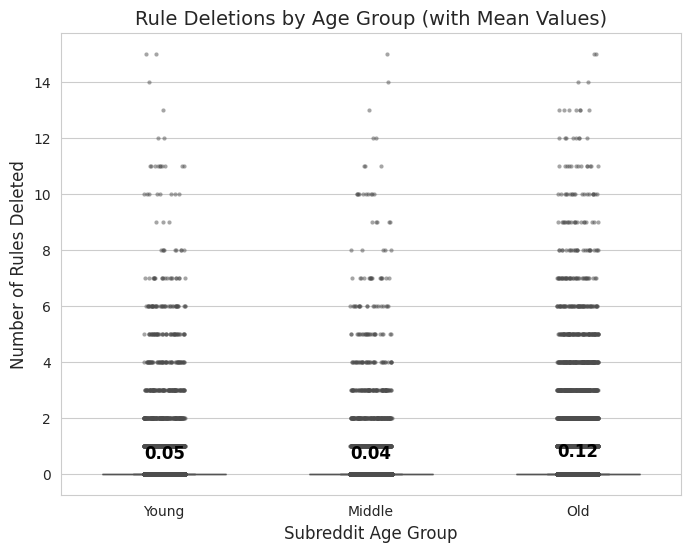

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define color palette
palette = sns.color_palette("muted")

# Set up figure size
plt.figure(figsize=(8, 6))

# Create a Boxplot with Swarmplot overlay
sns.boxplot(x=df["age_group"], y=df["deleted"], palette=palette, width=0.6, showfliers=False)
sns.stripplot(x=df["age_group"], y=df["deleted"], color=".3", size=3, jitter=True, alpha=0.5)

# Compute means for annotation
means = df.groupby("age_group")["deleted"].mean()

# Add mean values as annotations above each box
for i, mean_val in enumerate(means):
    plt.text(i, mean_val + 0.5, f"{mean_val:.2f}", ha='center', fontsize=12, fontweight='bold', color="black")

# Titles & Labels
plt.title("Rule Deletions by Age Group (with Mean Values)", fontsize=14)
plt.xlabel("Subreddit Age Group", fontsize=12)
plt.ylabel("Number of Rules Deleted", fontsize=12)

# Show plot
plt.show()

In [ ]:
# Standardize (Z-score normalization)
df["subscribers_1_scaled"] = (df["subscribers_1"] - df["subscribers_1"].mean()) / df["subscribers_1"].std()
df["age_in_months_scaled"] = (df["age_in_months"] - df["age_in_months"].mean()) / df["age_in_months"].std()
df["rules_1_scaled"] = (df["rules_1"] - df["rules_1"].mean()) / df["rules_1"].std()

# Log-Transform Highly Skewed Variables
df["log_subscribers_1"] = np.log1p(df["subscribers_1"])  # log(1 + x) to avoid log(0)

# Check for Multicollinearity (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[["subscribers_1", "age_in_months", "rules_1"]]
X = sm.add_constant(X)  # Add intercept

# Compute VIF for each variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\nVariance Inflation Factor (VIF) for Multicollinearity Detection:")
print(vif_data)


Variance Inflation Factor (VIF) for Multicollinearity Detection:
        Variable       VIF
0          const  4.069145
1  subscribers_1  1.021454
2  age_in_months  1.023833
3        rules_1  1.015773


In [ ]:
# Run Regression Again with Scaled/Log Variables
model_fixed = smf.ols("added ~ log_subscribers_1 + age_in_months_scaled + rules_1_scaled", data=df).fit()
print("\nFixed Regression: Rules Added ~ Log(Subs) + Age + Initial Rules")
print(model_fixed.summary())

model_fixed_deleted = smf.ols("deleted ~ log_subscribers_1 + age_in_months_scaled + rules_1_scaled", data=df).fit()
print("\nFixed Regression: Rules Deleted ~ Log(Subs) + Age + Initial Rules")
print(model_fixed_deleted.summary())


Fixed Regression: Rules Added ~ Log(Subs) + Age + Initial Rules
                            OLS Regression Results                            
Dep. Variable:                  added   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     2270.
Date:                Sun, 02 Mar 2025   Prob (F-statistic):               0.00
Time:                        06:23:52   Log-Likelihood:            -1.4763e+05
No. Observations:              130851   AIC:                         2.953e+05
Df Residuals:                  130847   BIC:                         2.953e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

## 12 May 2025


Share‑of‑rules‑changed summary (punctuation test)
count    130851.000000
mean          0.047923
std           0.331705
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          15.000000


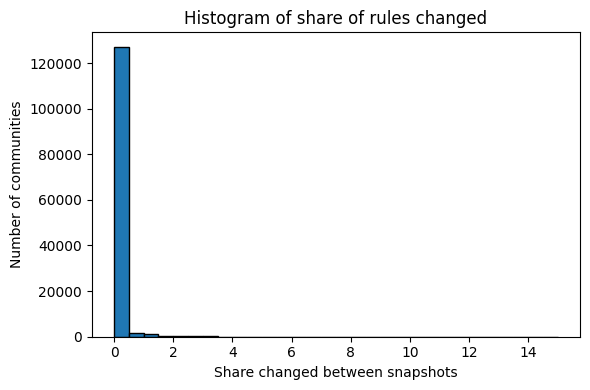


Over‑dispersion test
  Variance‑to‑mean ratio (VMR): 0.947
  χ²(130850) = 123,903.0,  p = 1

Simulation test (10 000 reps)
  Observed ‘bundle‑like’ communities (≥75 % rules changed): 2638
  Simulation mean ± sd: 1405.50 ± 37.20
  95 % simulated interval: [1332, 1479]
  One‑sided p‑value: p = 9.999e-05


/usr/local/lib/python3.11/dist-packages/statsmodels/discrete/discrete_model.py:1567: RuntimeWarning: overflow encountered in exp
  L = np.exp(np.dot(X,params) + exposure + offset)
/usr/local/lib/python3.11/dist-packages/statsmodels/discrete/discrete_model.py:1478: RuntimeWarning: overflow encountered in exp
  L = np.exp(np.dot(X,params) + offset + exposure)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Negative‑binomial regression on number of rules changed
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const             nan        nan        nan        nan         nan         nan
log_rules         nan        nan        nan        nan         nan         nan
age_years         nan        nan        nan        nan         nan         nan
delta_subs        nan        nan        nan        nan         nan         nan
alpha          1.0513        nan        nan        nan         nan         nan


In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# 0.  Imports  (safe to re‑run; will overwrite nothing)
# ------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
plt.style.use('default')
# ──────────────────────────────────────────────────────────────────────────────


# ──────────────────────────────────────────────────────────────────────────────
# 1.  Housekeeping / derived variables
# ------------------------------------------------------------------------------
# share of rules changed
df['share_changed'] = (
    df[['added', 'changed', 'deleted']].sum(axis=1) / df['rules_1']
)

# age in years
df['age_in_years'] = df['age_in_months'] / 12

# subscriber growth (can be negative)
df['delta_subs'] = df['subscribers_2'] - df['subscribers_1']


# ──────────────────────────────────────────────────────────────────────────────
# 2.  Distributional evidence
# ------------------------------------------------------------------------------
print("\nShare‑of‑rules‑changed summary (punctuation test)")
print(df['share_changed'].describe().to_string())

plt.figure(figsize=(6,4))
plt.hist(df['share_changed'], bins=30, edgecolor='k')
plt.title("Histogram of share of rules changed")
plt.xlabel("Share changed between snapshots")
plt.ylabel("Number of communities")
plt.tight_layout()
plt.show()


# ──────────────────────────────────────────────────────────────────────────────
# 3.  Over‑dispersion (variance‑to‑mean ratio test)
# ------------------------------------------------------------------------------
change_flag = (df[['added','changed','deleted']].sum(axis=1) > 0).astype(int)
vmr = change_flag.var(ddof=0) / change_flag.mean()
chi2_obs = (len(change_flag)-1) * change_flag.var(ddof=1) / change_flag.mean()
p_val_vmr = 1 - stats.chi2.cdf(chi2_obs, df=len(change_flag)-1)

print(f"\nOver‑dispersion test")
print(f"  Variance‑to‑mean ratio (VMR): {vmr:.3f}")
print(f"  χ²({len(change_flag)-1:d}) = {chi2_obs:,.1f},  p = {p_val_vmr:.4g}")


# ──────────────────────────────────────────────────────────────────────────────
# 4.  Counterfactual simulation
# ------------------------------------------------------------------------------
n_rules   = df['rules_1'].to_numpy()
p_rule    = df[['added','changed','deleted']].sum().sum() / n_rules.sum()
observed_bundle_ct = (df['share_changed'] >= 0.75).sum()

def simulate_bundle_count(n_rules_vec, p_edit):
    draws = np.random.binomial(n_rules_vec, p_edit)
    return (draws >= 0.75 * n_rules_vec).sum()

sim_counts = np.array([simulate_bundle_count(n_rules, p_rule) for _ in range(10_000)])
p_sim = (np.sum(sim_counts >= observed_bundle_ct) + 1) / (len(sim_counts) + 1)

print(f"\nSimulation test (10 000 reps)")
print(f"  Observed ‘bundle‑like’ communities (≥75 % rules changed): {observed_bundle_ct}")
print(f"  Simulation mean ± sd: {sim_counts.mean():.2f} ± {sim_counts.std():.2f}")
print(f"  95 % simulated interval: [{np.percentile(sim_counts,2.5):.0f}, "
      f"{np.percentile(sim_counts,97.5):.0f}]")
print(f"  One‑sided p‑value: p = {p_sim:.4g}")